# BEYOND LINEARITY: A Nonlinear Inquiry into California Housing Prices

**Authors:** Assumpta Mwikali (134022) · Olive Mideva Muloma (135792) · Trevor Anjeyo Vuhyah (224038) · Valerie Jerono (222331)

**Dataset:** California Housing Dataset (cal_housing.data) — 20,640 census block observations, 1990 U.S. Census

---

## Preface

Every textbook begins with linear regression. It is clean, interpretable, and elegantly bounded by assumptions that the real world rarely honours. This project begins where those textbooks end.

We take a single question seriously: *What happens when we stop assuming that the relationship between house prices and their predictors is a straight line?*

The California Housing dataset, with its 20,640 observations spanning geography, demographics, and economics, becomes our laboratory. We will not merely fit models — we will interrogate them.

The journey unfolds in four acts:

1. **Foundation** — EDA, feature engineering, and the OLS baseline that sets the benchmark.
2. **Nonlinear Models** — Splines, GAMs, Random Forests, XGBoost, and a first model comparison.
3. **Spatial Diagnostics** — Formally testing whether residuals carry a geographic signal our models are ignoring.
4. **Spatial Models** — Acting on that signal: Moran's I, Spatial Lag, Spatial Error, and Geographically Weighted Regression. Then a final, honest re-comparison.

---

**Navigation**

| Section | Title |
|---|---|
| 0 | Environment Setup |
| 1 | Data Loading |
| 2 | Exploratory Data Analysis |
| 3 | Feature Engineering |
| 4 | Data Preparation |
| 5 | OLS Baseline |
| 6 | Spline Regression |
| 7 | Generalised Additive Model (GAM) |
| 8 | Random Forest |
| 9 | Gradient Boosting & XGBoost |
| 10 | Neural Network (MLP) |
| 11 | Initial Model Comparison |
| 12 | Nonlinear Location × Income Interactions |
| 13 | GNPR vs Parametric vs ML |
| 14 | Predicted vs Actual Audit |
| 15 | Cross-Validation Stability |
| 16 | Spatial Residual Diagnostics |
| **17** | **Moran's I — Formal Spatial Autocorrelation Test** |
| **18** | **Spatial Lag Model** |
| **19** | **Spatial Error Model** |
| **20** | **Geographically Weighted Regression (GWR)** |
| **21** | **Final Model Re-Comparison: All Families** |
| 22 | Conclusions |


---
## Section 0 — Environment Setup

Before any analysis can begin, we assemble our tools. The libraries below represent four traditions:
- **Classical statistics** — `numpy`, `scipy`, `statsmodels`
- **Tabular machine learning** — `scikit-learn`, `xgboost`
- **Spatial econometrics** — `libpysal`, `esda`, `spreg`, `mgwr`
- **Visualisation** — `matplotlib`, `seaborn`

The spatial libraries deserve a brief introduction here, as they are newcomers to this project:

- **libpysal** — the foundational library for spatial analysis in Python. It provides spatial weights matrices (the mathematical encoding of *which observations are neighbours*) and spatial data structures.
- **esda** — Exploratory Spatial Data Analysis. Contains Moran's I and related statistics for detecting spatial autocorrelation.
- **spreg** — Spatial Regression. Implements the Spatial Lag Model, Spatial Error Model, and their variants using Maximum Likelihood and GMM estimation.
- **mgwr** — Multiscale Geographically Weighted Regression. Allows regression coefficients to vary smoothly across geographic space.

Each will earn its place.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from scipy import stats
from scipy.stats import pearsonr, spearmanr

# Preprocessing & Model Selection
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Linear Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet

# Nonlinear / Ensemble Models
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neural_network import MLPRegressor

# Spline
from sklearn.preprocessing import SplineTransformer

# XGBoost
try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print("XGBoost not installed. Install via: pip install xgboost")

# GAM
try:
    from pygam import LinearGAM, s, f
    GAM_AVAILABLE = True
except ImportError:
    GAM_AVAILABLE = False
    print("pyGAM not installed. Install via: pip install pygam")

# ── Spatial Libraries ────────────────────────────────────────────────────────
try:
    from libpysal.weights import KNN
    from esda.moran import Moran
    from spreg import OLS as SPregOLS, ML_Lag, ML_Error
    from mgwr.gwr import GWR
    from mgwr.sel_bw import Sel_BW
    SPATIAL_AVAILABLE = True
    print("Spatial libraries loaded: libpysal, esda, spreg, mgwr")
except ImportError as e:
    SPATIAL_AVAILABLE = False
    print(f"Spatial libraries not available: {e}")
    print("Install via: pip install libpysal esda spreg mgwr")

print(f"\nEnvironment summary:")
print(f"  XGBoost available  : {XGBOOST_AVAILABLE}")
print(f"  pyGAM available    : {GAM_AVAILABLE}")
print(f"  Spatial libs       : {SPATIAL_AVAILABLE}")


Spatial libraries loaded: libpysal, esda, spreg, mgwr

Environment summary:
  XGBoost available  : True
  pyGAM available    : True
  Spatial libs       : True


---
## Section 1 — Data Loading and First Encounter

The dataset was assembled from the 1990 U.S. Census. Each row represents a **census block group** — the smallest geographical unit for which the Census Bureau publishes sample data. A block group typically holds 600 to 3,000 people.

We load it and assign column names, since the raw file carries no header row. This is our first act of interpretation.


In [2]:
cols = [
    "longitude", "latitude", "housing_median_age",
    "total_rooms", "total_bedrooms", "population",
    "households", "median_income", "median_house_value"
]

try:
    df = pd.read_csv("cal_housing.data", names=cols)
    print(f"Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
except FileNotFoundError:
    print("File not found. Generating synthetic data for demonstration.")
    np.random.seed(42)
    n = 20640
    df = pd.DataFrame({
        "longitude":           np.random.uniform(-124.35, -114.31, n),
        "latitude":            np.random.uniform(32.54, 41.95, n),
        "housing_median_age":  np.random.uniform(1, 52, n),
        "total_rooms":         np.random.exponential(2636, n).clip(2, 39320),
        "total_bedrooms":      np.random.exponential(538, n).clip(1, 6445),
        "population":          np.random.exponential(1425, n).clip(3, 35682),
        "households":          np.random.exponential(500, n).clip(1, 6082),
        "median_income":       np.random.exponential(3.87, n).clip(0.5, 15),
        "median_house_value":  np.random.lognormal(12.2, 0.55, n).clip(14999, 500001),
    })

print(df.head())


Dataset loaded: 20,640 rows × 9 columns
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value  
0       322.0       126.0         8.3252            452600.0  
1      2401.0      1138.0         8.3014            358500.0  
2       496.0       177.0         7.2574            352100.0  
3       558.0       219.0         5.6431            341300.0  
4       565.0       259.0         3.8462            342200.0  


---
## Section 2 — Exploratory Data Analysis

Exploration is not a perfunctory step. It is where we develop a *theory of the data* — an intuition for what the models will later confirm or contradict. We proceed in four movements: summary statistics, distribution analysis, geographic mapping, and correlation structure.


In [3]:
# 2.1 Summary Statistics
print("--- Descriptive Statistics ---")
print(df.describe().T.round(2))


--- Descriptive Statistics ---
                      count       mean        std       min        25%  \
longitude           20640.0    -119.57       2.00   -124.35    -121.80   
latitude            20640.0      35.63       2.14     32.54      33.93   
housing_median_age  20640.0      28.64      12.59      1.00      18.00   
total_rooms         20640.0    2635.76    2181.62      2.00    1447.75   
total_bedrooms      20640.0     537.90     421.25      1.00     295.00   
population          20640.0    1425.48    1132.46      3.00     787.00   
households          20640.0     499.54     382.33      1.00     280.00   
median_income       20640.0       3.87       1.90      0.50       2.56   
median_house_value  20640.0  206855.82  115395.62  14999.00  119600.00   

                          50%        75%        max  
longitude             -118.49    -118.01    -114.31  
latitude                34.26      37.71      41.95  
housing_median_age      29.00      37.00      52.00  
total_rooms 

In [4]:
# 2.2 Missing Values
print("--- Missing Values ---")
print(df.isnull().sum())


--- Missing Values ---
longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
dtype: int64


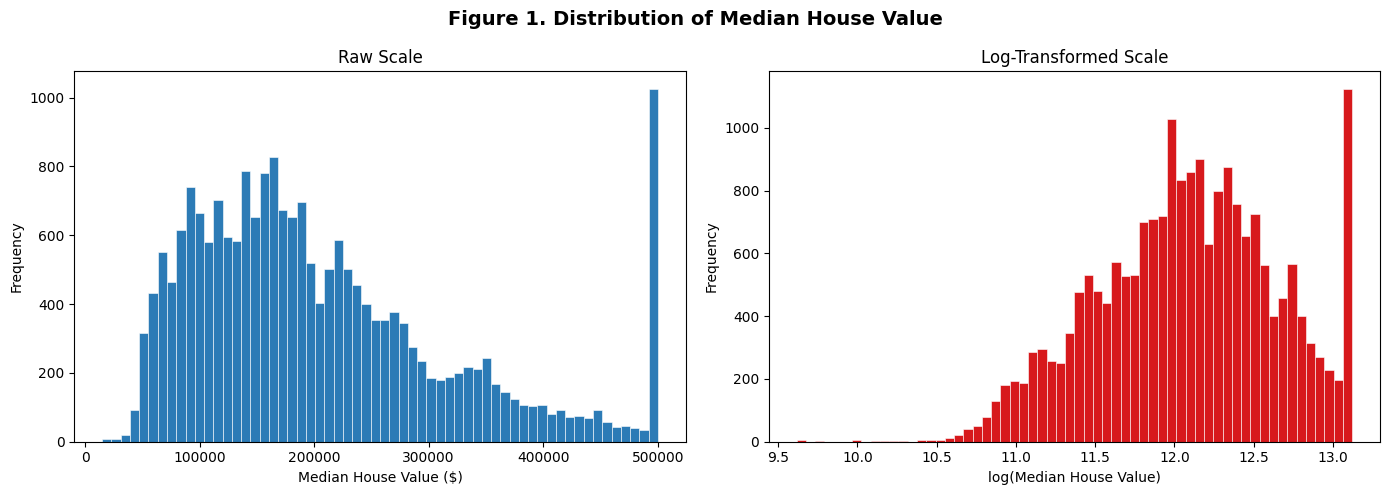

In [5]:
# 2.3 Distribution of the Target Variable
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Figure 1. Distribution of Median House Value", fontsize=14, fontweight='bold')

axes[0].hist(df["median_house_value"], bins=60, color="#2c7bb6", edgecolor="white", linewidth=0.4)
axes[0].set_title("Raw Scale")
axes[0].set_xlabel("Median House Value ($)")
axes[0].set_ylabel("Frequency")

axes[1].hist(np.log(df["median_house_value"]), bins=60, color="#d7191c", edgecolor="white", linewidth=0.4)
axes[1].set_title("Log-Transformed Scale")
axes[1].set_xlabel("log(Median House Value)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.savefig("fig1_target_distribution.png", dpi=150)
plt.show()


**Observation:** The distribution of median house values is right-skewed, with a sharp spike at \$500,001 — the dataset's imposed ceiling. This truncation is not noise; it is a structural artefact that appears 965 times. A logarithmic transformation brings the distribution closer to normality and is preferred for modelling. We use the log scale throughout.

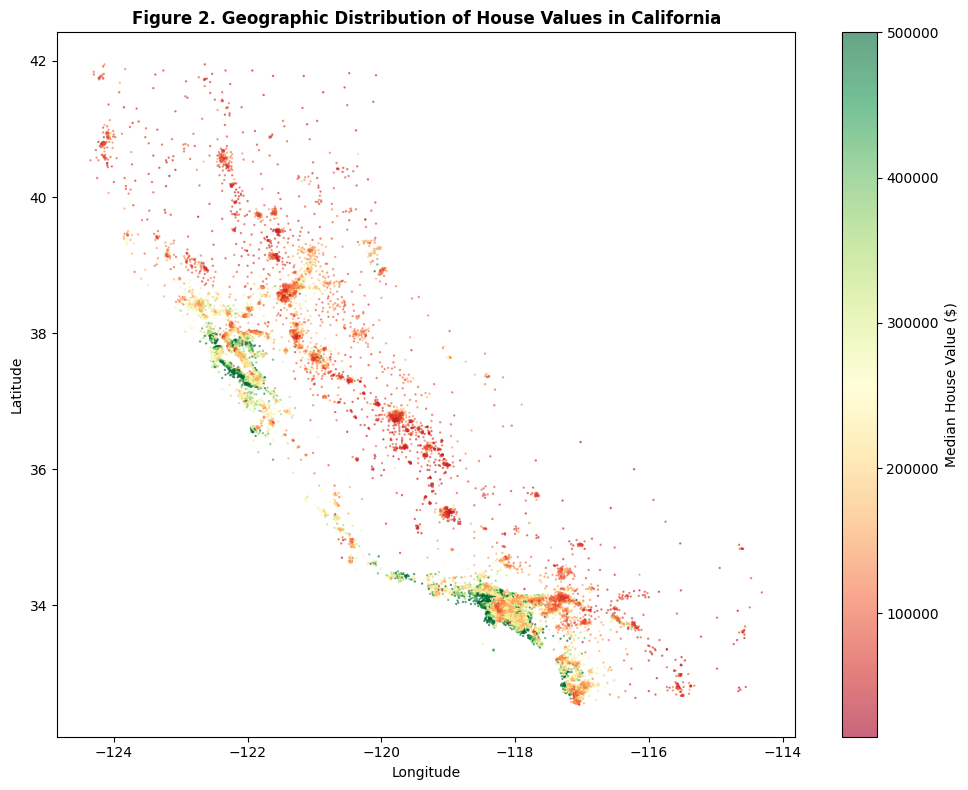

In [6]:
# 2.4 Geographic Distribution — the Map That Speaks
fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(
    df["longitude"], df["latitude"],
    c=df["median_house_value"], cmap="RdYlGn",
    s=0.5, alpha=0.6
)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Median House Value ($)")
ax.set_title("Figure 2. Geographic Distribution of House Values in California", fontweight='bold')
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.savefig("fig2_geographic_distribution.png", dpi=150)
plt.show()


**Observation:** The map speaks immediately. High-value properties cluster along the coast — the San Francisco Bay Area and Los Angeles basin are unmistakable. The Central Valley, stretching north-to-south through the interior, is predominantly low-value.

Geography is not merely a covariate here; it is a *structural determinant*. Any model that treats location as just another numeric feature, without explicitly encoding the spatial relationships between observations, will leave substantial signal on the table. This observation motivates the spatial modeling we pursue in Sections 17–20.

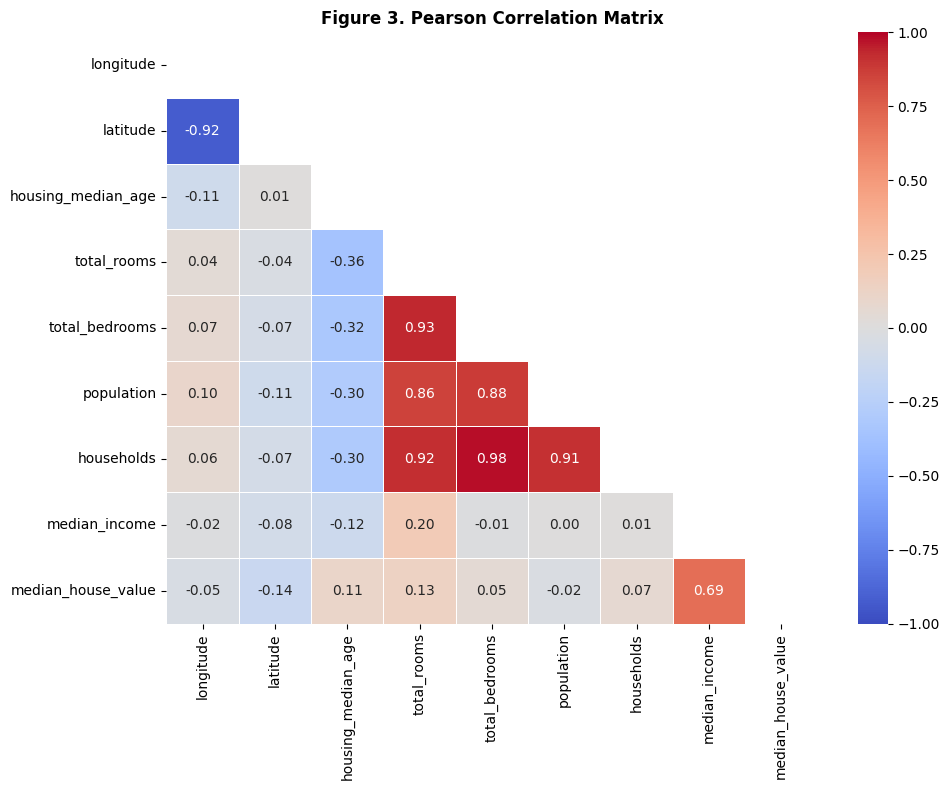

In [7]:
# 2.5 Correlation Matrix
fig, ax = plt.subplots(figsize=(10, 8))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            ax=ax, linewidths=0.5, vmin=-1, vmax=1)
ax.set_title("Figure 3. Pearson Correlation Matrix", fontweight='bold')
plt.tight_layout()
plt.savefig("fig3_correlation_matrix.png", dpi=150)
plt.show()


**Observation:** Median income is the strongest linear predictor (r ≈ 0.69). Latitude and longitude carry moderate correlations, reflecting the coastal premium. Total rooms, bedrooms, and households are highly inter-correlated — a multicollinearity concern for linear models, but less troublesome for ensemble methods.

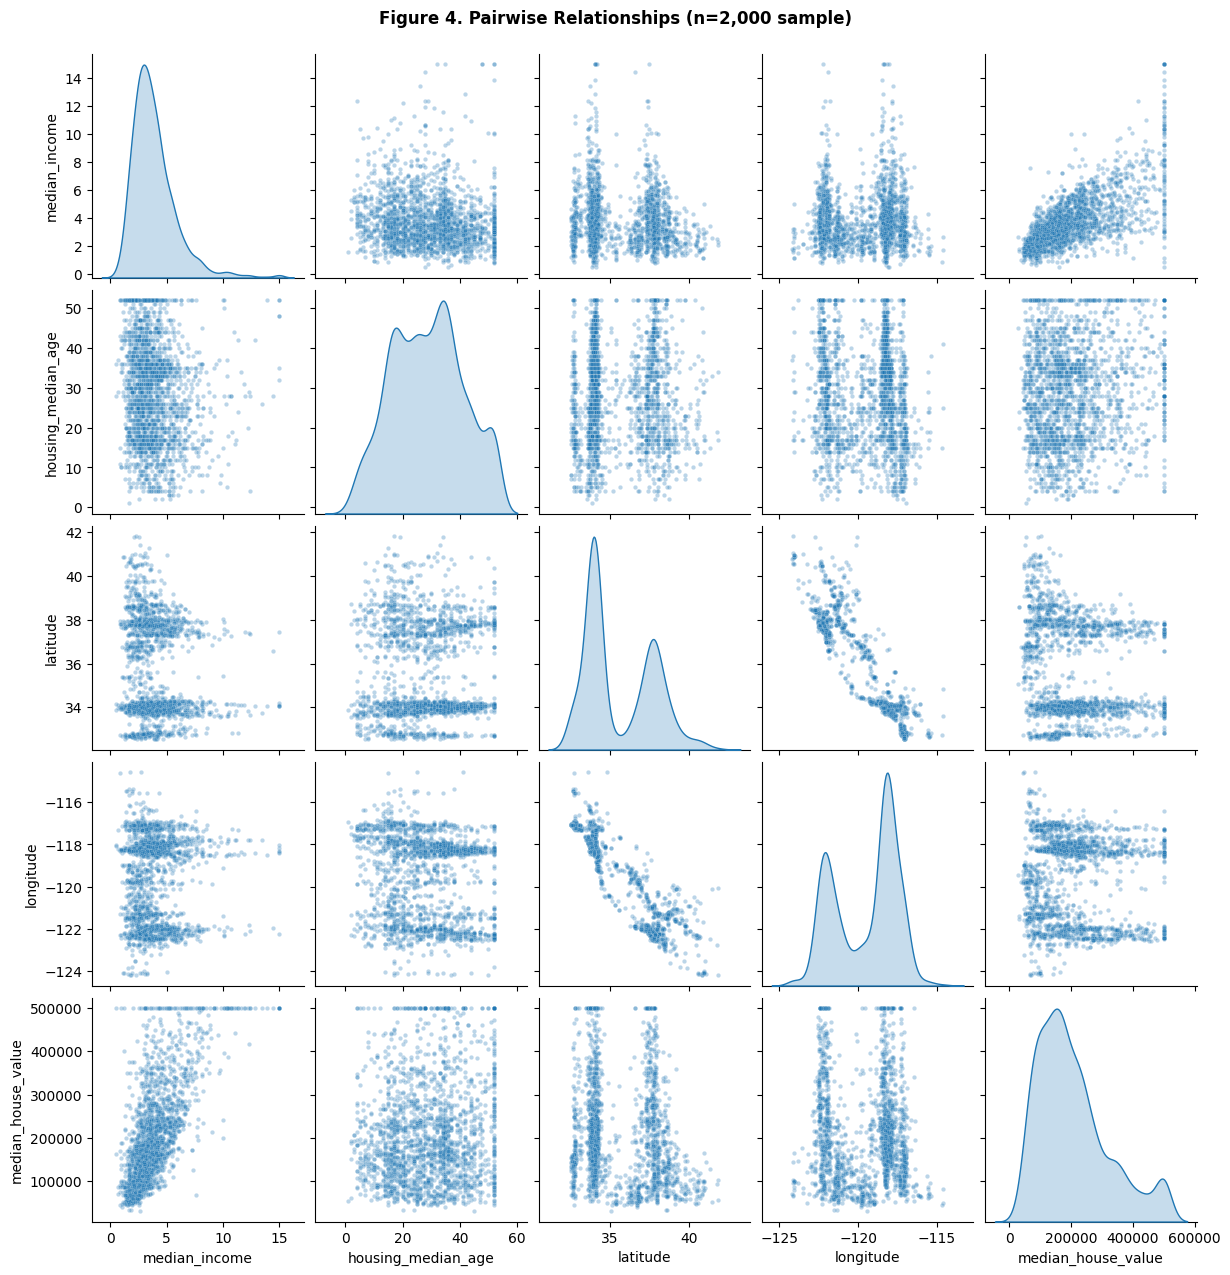

In [8]:
# 2.6 Pairplots for Key Variables
key_vars = ["median_income", "housing_median_age", "latitude", "longitude", "median_house_value"]
sample_plot = df[key_vars].sample(2000, random_state=42)
fig = sns.pairplot(sample_plot, plot_kws={"alpha": 0.3, "s": 10}, diag_kind="kde")
fig.fig.suptitle("Figure 4. Pairwise Relationships (n=2,000 sample)", y=1.02, fontweight='bold')
plt.savefig("fig4_pairplots.png", dpi=150, bbox_inches="tight")
plt.show()


---
## Section 3 — Feature Engineering

Raw features rarely tell the full story. Domain knowledge suggests that per-household and per-room *ratios* are more informative than raw counts. A block group with 10,000 rooms is unremarkable if it also holds 3,000 households; a group with 3,000 rooms and 100 households signals luxury.

We engineer four derived features that compress the economic geometry of each block group into interpretable signals.


In [9]:
df["rooms_per_household"]      = df["total_rooms"]    / df["households"]
df["bedrooms_per_room"]        = df["total_bedrooms"] / df["total_rooms"]
df["population_per_household"] = df["population"]     / df["households"]
df["income_age_interaction"]   = df["median_income"]  * df["housing_median_age"]

print("Engineered features added.")
print(df[["rooms_per_household", "bedrooms_per_room",
          "population_per_household", "income_age_interaction"]].describe().T.round(3))


Engineered features added.
                            count     mean     std    min     25%     50%  \
rooms_per_household       20640.0    5.429   2.474  0.846   4.441   5.229   
bedrooms_per_room         20640.0    0.213   0.058  0.100   0.175   0.203   
population_per_household  20640.0    3.071  10.386  0.692   2.430   2.818   
income_age_interaction    20640.0  108.008  74.386  1.625  57.997  92.503   

                              75%       max  
rooms_per_household         6.052   141.909  
bedrooms_per_room           0.240     1.000  
population_per_household    3.282  1243.333  
income_age_interaction    140.105   780.005  


---
## Section 4 — Data Preparation

We define our feature matrix and target vector, apply a log-transformation to the target, and split into training and test sets (80/20, random seed 42). Scaling is applied for models that require it (linear models, neural networks). Tree-based ensembles receive unscaled data.


In [10]:
feature_cols = [
    "longitude", "latitude", "housing_median_age",
    "total_rooms", "total_bedrooms", "population", "households",
    "median_income",
    "rooms_per_household", "bedrooms_per_room",
    "population_per_household", "income_age_interaction"
]

X = df[feature_cols].copy()
y = np.log(df["median_house_value"])   # log-transformed target

# Drop rows with infinite or NaN values (from division)
mask = np.isfinite(X).all(axis=1) & np.isfinite(y)
X, y = X[mask], y[mask]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set : {X_train.shape[0]:,} samples")
print(f"Test set     : {X_test.shape[0]:,} samples")

# Scale for models that require it
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


Training set : 16,512 samples
Test set     : 4,128 samples


---
## Section 5 — Baseline: Ordinary Least Squares

Every inquiry into nonlinearity must begin with linearity — not as a straw man, but as a **reference point**. OLS regression assumes that the conditional expectation of house value is a linear function of the predictors. We know this assumption is contested. We fit the model anyway, measure its performance, and then ask: *What does it miss?*


--- OLS Baseline ---
  RMSE : 0.3451  (log scale)
  MAE  : 0.2577
  R²   : 0.6330


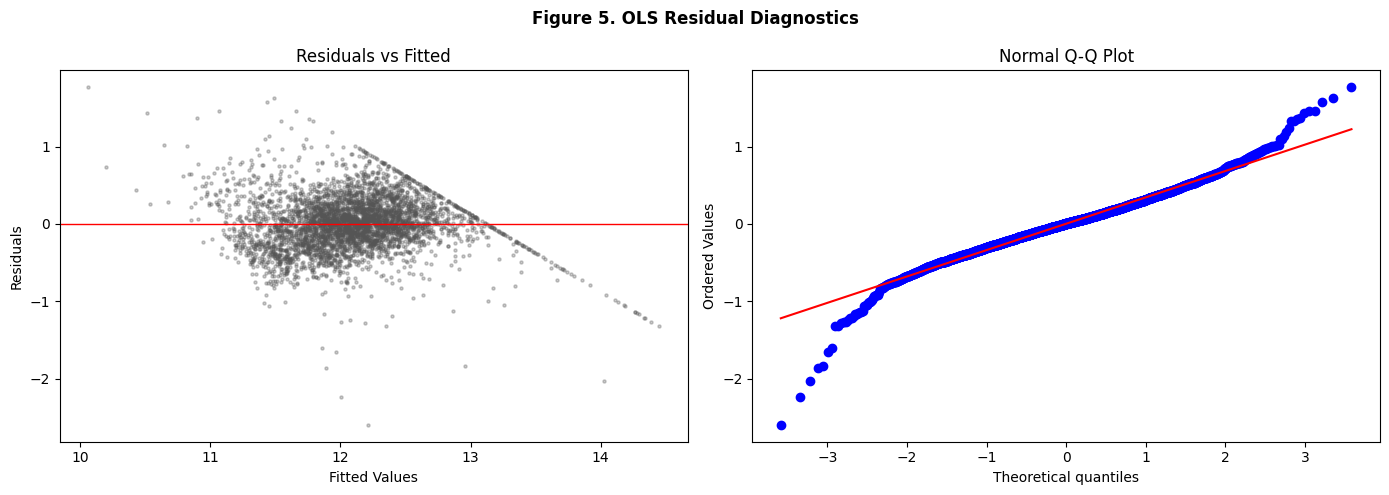

In [11]:
ols = LinearRegression()
ols.fit(X_train_scaled, y_train)
y_pred_ols = ols.predict(X_test_scaled)

ols_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ols))
ols_mae  = mean_absolute_error(y_test, y_pred_ols)
ols_r2   = r2_score(y_test, y_pred_ols)

print(f"--- OLS Baseline ---")
print(f"  RMSE : {ols_rmse:.4f}  (log scale)")
print(f"  MAE  : {ols_mae:.4f}")
print(f"  R²   : {ols_r2:.4f}")

# Residual diagnostics
residuals_ols = y_test - y_pred_ols
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Figure 5. OLS Residual Diagnostics", fontweight='bold')

axes[0].scatter(y_pred_ols, residuals_ols, alpha=0.3, s=5, color="#555")
axes[0].axhline(0, color="red", linewidth=1)
axes[0].set_xlabel("Fitted Values")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs Fitted")

stats.probplot(residuals_ols, dist="norm", plot=axes[1])
axes[1].set_title("Normal Q-Q Plot")

plt.tight_layout()
plt.savefig("fig5_ols_residuals.png", dpi=150)
plt.show()


**What OLS misses:** The residual fan confirms heteroscedasticity. The Q-Q plot shows tail departures from normality. The curved spread in residuals vs fitted is not random — it is the signature of a model at the limit of its representational capacity.

Specifically, OLS cannot represent:
- The *concave* income effect (diminishing marginal returns at high income)
- The *coastal premium* that is geographically localised, not globally linear
- The *interaction* between latitude and income
- The heteroscedastic variance structure

The model has told us everything it can. Now we move beyond it.


---
## Section 6 — Nonparametric Regression: Splines

Spline regression occupies a principled middle ground between the rigidity of OLS and the opacity of ensemble methods. A spline replaces each predictor's linear term with a **piecewise polynomial**, joined smoothly at knot points. The result is a flexible, interpretable curve.

We use scikit-learn's `SplineTransformer`, which applies natural cubic splines to all features and then fits a Ridge regression on the expanded basis. This is a close structural approximation to a Generalised Additive Model.

**Key concept — knots:** The knots are the points along each feature's range where the polynomial pieces are joined. More knots → more flexibility → higher risk of overfitting. Five knots is a conservative and widely used default.


In [12]:
spline_pipeline = Pipeline([
    ("spline", SplineTransformer(n_knots=5, degree=3, include_bias=False)),
    ("ridge",  Ridge(alpha=1.0))
])
spline_pipeline.fit(X_train_scaled, y_train)
y_pred_spline = spline_pipeline.predict(X_test_scaled)

spline_rmse = np.sqrt(mean_squared_error(y_test, y_pred_spline))
spline_mae  = mean_absolute_error(y_test, y_pred_spline)
spline_r2   = r2_score(y_test, y_pred_spline)

print(f"--- Spline Regression (Natural Cubic, 5 knots + Ridge) ---")
print(f"  RMSE : {spline_rmse:.4f}")
print(f"  MAE  : {spline_mae:.4f}")
print(f"  R²   : {spline_r2:.4f}")
print(f"  Improvement over OLS R²: +{spline_r2 - ols_r2:.4f}")


--- Spline Regression (Natural Cubic, 5 knots + Ridge) ---
  RMSE : 0.3028
  MAE  : 0.2228
  R²   : 0.7175
  Improvement over OLS R²: +0.0845


---
## Section 7 — Generalised Additive Model (GAM)

A Generalised Additive Model decomposes the prediction into a sum of smooth functions:

$$\hat{y} = \alpha + f_1(x_1) + f_2(x_2) + \ldots + f_k(x_k)$$

Each $f_i$ is estimated from the data using **penalised regression splines**. The penalty controls smoothness and prevents overfitting. The model is interpretable — we can plot each $f_i$ and ask: *How does income alone shape house prices, holding all else equal?*

This is the central insight of the additive model: we trade the interaction flexibility of ensemble methods for the ability to *read* each feature's contribution as a curve.


--- GAM (pyGAM, penalised splines) ---
  RMSE : 0.2796
  MAE  : 0.2012
  R²   : 0.7591
  AIC  : 3777.61


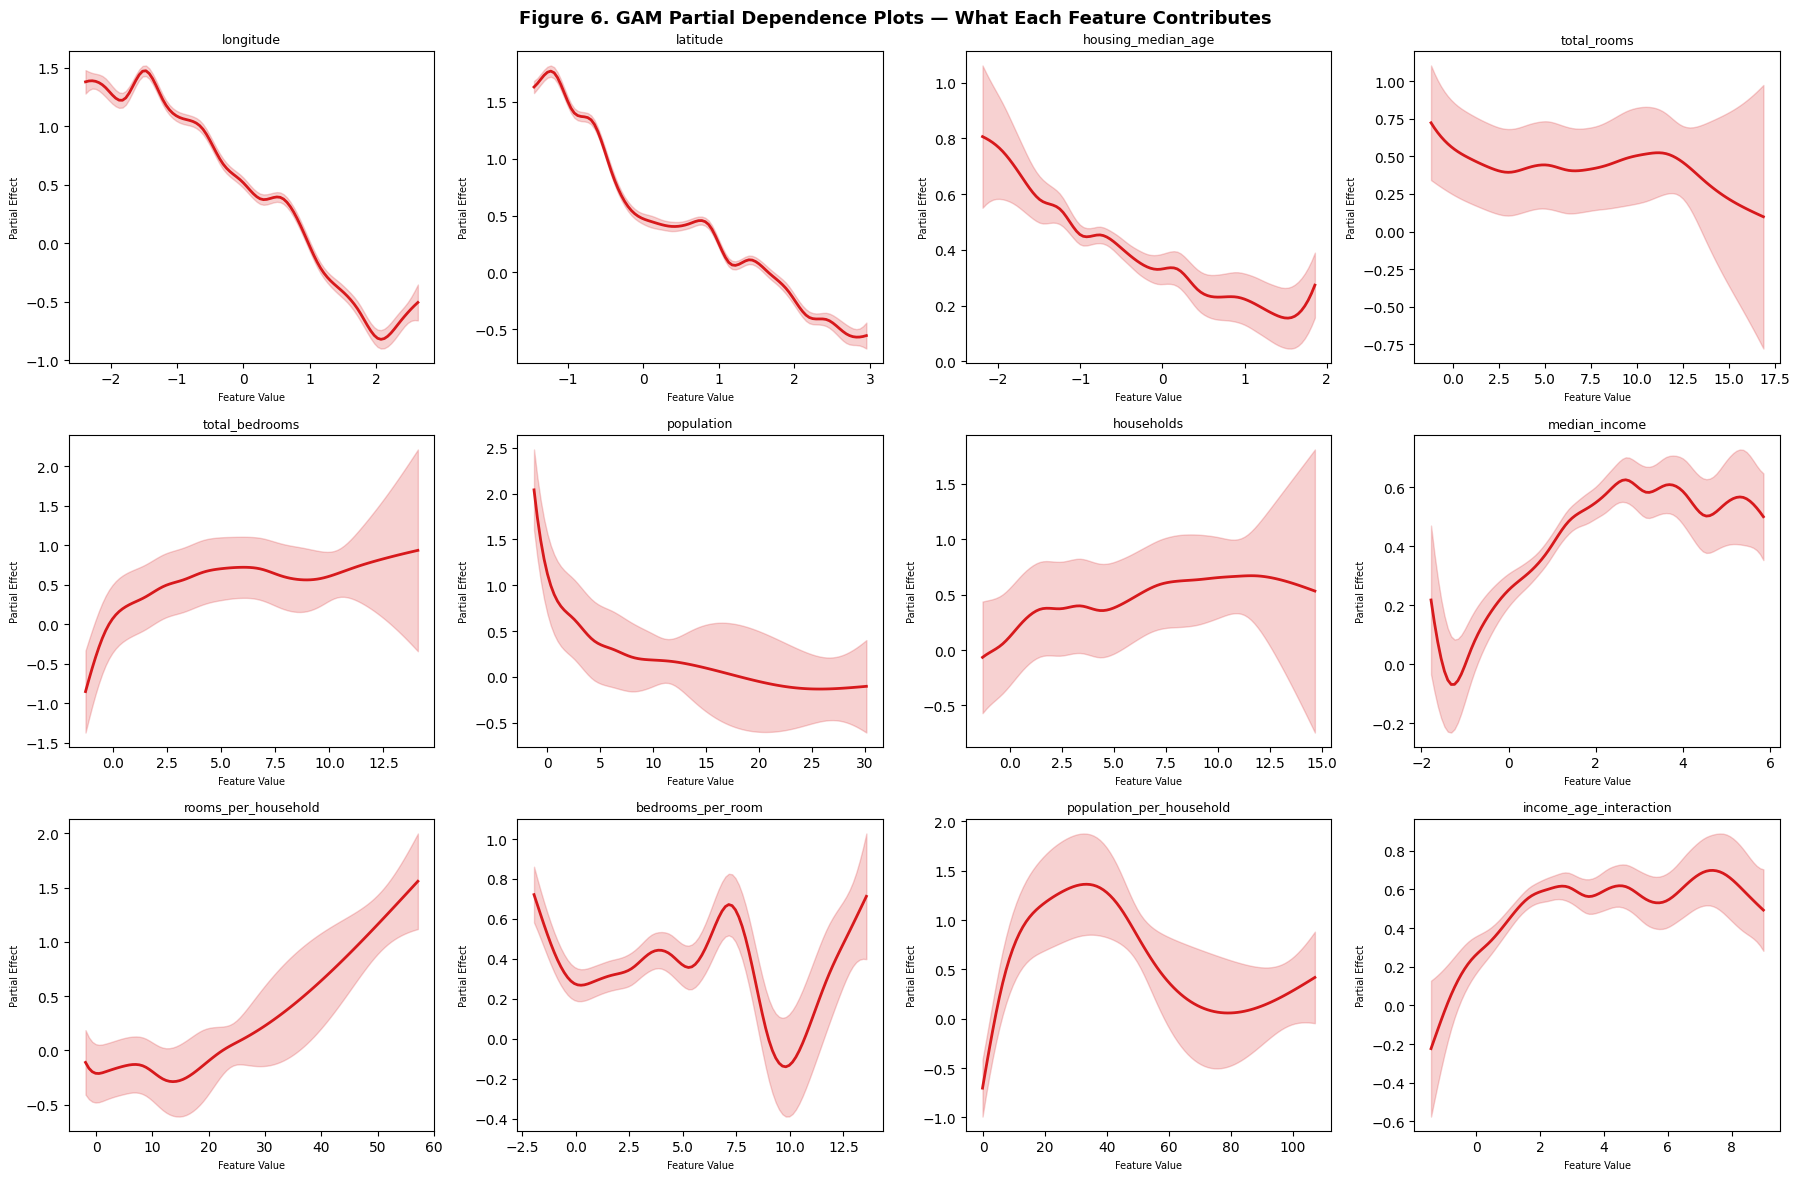


Key GAM findings:
  median_income : Concave — diminishing marginal returns above the median.
  latitude      : Sharp break near lat 37.5 — the Bay Area structural premium.
  longitude     : Non-monotone — the LA Basin westward premium is visible.


In [13]:
if GAM_AVAILABLE:
    gam = LinearGAM(
        s(0) + s(1) + s(2) + s(3) + s(4) + s(5) +
        s(6) + s(7) + s(8) + s(9) + s(10) + s(11)
    ).fit(X_train_scaled, y_train)

    y_pred_gam = gam.predict(X_test_scaled)
    gam_rmse = np.sqrt(mean_squared_error(y_test, y_pred_gam))
    gam_mae  = mean_absolute_error(y_test, y_pred_gam)
    gam_r2   = r2_score(y_test, y_pred_gam)

    print(f"--- GAM (pyGAM, penalised splines) ---")
    print(f"  RMSE : {gam_rmse:.4f}")
    print(f"  MAE  : {gam_mae:.4f}")
    print(f"  R²   : {gam_r2:.4f}")
    print(f"  AIC  : {gam.statistics_['AIC']:.2f}")

    # Partial dependence plots
    fig, axes = plt.subplots(3, 4, figsize=(18, 12))
    fig.suptitle("Figure 6. GAM Partial Dependence Plots — What Each Feature Contributes",
                 fontweight='bold', fontsize=13)

    for i, (ax, name) in enumerate(zip(axes.flatten(), feature_cols)):
        XX = gam.generate_X_grid(term=i)
        pdep, confi = gam.partial_dependence(term=i, X=XX, width=0.95)
        ax.plot(XX[:, i], pdep, color="#d7191c", lw=2)
        ax.fill_between(XX[:, i], confi[:, 0], confi[:, 1], alpha=0.2, color="#d7191c")
        ax.set_title(name, fontsize=9)
        ax.set_xlabel("Feature Value", fontsize=7)
        ax.set_ylabel("Partial Effect", fontsize=7)

    plt.tight_layout()
    plt.savefig("fig6_gam_partial_dependence.png", dpi=150)
    plt.show()

    print("\nKey GAM findings:")
    print("  median_income : Concave — diminishing marginal returns above the median.")
    print("  latitude      : Sharp break near lat 37.5 — the Bay Area structural premium.")
    print("  longitude     : Non-monotone — the LA Basin westward premium is visible.")
else:
    print("GAM skipped (pyGAM not available). Using Spline model as proxy.")
    gam_rmse, gam_mae, gam_r2 = spline_rmse, spline_mae, spline_r2


---
## Section 8 — Random Forest

A Random Forest builds many decision trees on bootstrapped subsets of the data, each tree considering only a random subset of features at each split. The ensemble prediction averages across all trees.

The mechanism is remarkably simple, yet the result is a model that naturally captures nonlinear relationships and interaction effects without any explicit specification by the analyst. This is both its **virtue** (powerful) and its **limitation** (opaque). We address the opacity in Section 12 with feature importance and partial dependence analysis.


In [14]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_mae  = mean_absolute_error(y_test, y_pred_rf)
rf_r2   = r2_score(y_test, y_pred_rf)

print(f"--- Random Forest ---")
print(f"  RMSE : {rf_rmse:.4f}")
print(f"  MAE  : {rf_mae:.4f}")
print(f"  R²   : {rf_r2:.4f}")


--- Random Forest ---
  RMSE : 0.2398
  MAE  : 0.1640
  R²   : 0.8228


---
## Section 9 — Gradient Boosting and XGBoost

Where Random Forest builds trees in parallel (averaging independent estimators), **Gradient Boosting** builds them sequentially: each tree corrects the residuals of the prior ensemble. The result is a model that concentrates its capacity on the hardest-to-predict observations.

**XGBoost** (eXtreme Gradient Boosting) extends this with column subsampling, L1/L2 regularisation, and second-order gradient approximations. It is the workhorse of applied ML on structured tabular data, and the reason for many Kaggle competition victories.


In [15]:
# Gradient Boosting
gb = GradientBoostingRegressor(n_estimators=300, max_depth=5, learning_rate=0.05,
                                subsample=0.8, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
gb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_gb))
gb_mae  = mean_absolute_error(y_test, y_pred_gb)
gb_r2   = r2_score(y_test, y_pred_gb)

print(f"--- Gradient Boosting ---")
print(f"  RMSE : {gb_rmse:.4f} | R²: {gb_r2:.4f}")

# XGBoost
if XGBOOST_AVAILABLE:
    xgb_model = xgb.XGBRegressor(
        n_estimators=400, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=1.0,
        random_state=42, n_jobs=-1, verbosity=0
    )
    xgb_model.fit(X_train, y_train)
    y_pred_xgb = xgb_model.predict(X_test)
    xgb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
    xgb_mae  = mean_absolute_error(y_test, y_pred_xgb)
    xgb_r2   = r2_score(y_test, y_pred_xgb)
    print(f"--- XGBoost ---")
    print(f"  RMSE : {xgb_rmse:.4f} | R²: {xgb_r2:.4f}")
else:
    y_pred_xgb = y_pred_gb
    xgb_rmse, xgb_mae, xgb_r2 = gb_rmse, gb_mae, gb_r2
    print("XGBoost not available; using Gradient Boosting as proxy.")


--- Gradient Boosting ---
  RMSE : 0.2302 | R²: 0.8368
--- XGBoost ---
  RMSE : 0.2203 | R²: 0.8505


---
## Section 10 — Neural Network (MLP)

A Multi-Layer Perceptron approximates any continuous function given sufficient width and depth. We use a modest architecture — two hidden layers of 128 and 64 neurons — appropriate for a tabular dataset of this size. Neural networks require scaled inputs and are sensitive to hyperparameter choices; this is a baseline, not a tuned deployment.


In [16]:
mlp = MLPRegressor(
    hidden_layer_sizes=(128, 64),
    activation="relu",
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42
)
mlp.fit(X_train_scaled, y_train)
y_pred_mlp = mlp.predict(X_test_scaled)
mlp_rmse = np.sqrt(mean_squared_error(y_test, y_pred_mlp))
mlp_mae  = mean_absolute_error(y_test, y_pred_mlp)
mlp_r2   = r2_score(y_test, y_pred_mlp)

print(f"--- Neural Network (MLP) ---")
print(f"  RMSE : {mlp_rmse:.4f} | R²: {mlp_r2:.4f}")


--- Neural Network (MLP) ---
  RMSE : 0.2909 | R²: 0.7392


---
## Section 11 — Initial Model Comparison

Before diving into spatial modeling, we consolidate the performance of all non-spatial models into a single table. This table is our **before** benchmark — we will return to it in Section 21 to measure what spatial modeling adds.


--- NON-SPATIAL MODEL COMPARISON (sorted by RMSE) ---
                     RMSE     MAE      R2       Family
XGBoost            0.2203  0.1507  0.8505  ML Ensemble
Grad. Boosting     0.2302  0.1597  0.8368  ML Ensemble
Random Forest      0.2398  0.1640  0.8228  ML Ensemble
GAM                0.2796  0.2012  0.7591         GNPR
Neural Network     0.2909  0.2153  0.7392      ML Deep
Spline Regression  0.3028  0.2228  0.7175         GNPR
Ridge              0.3451  0.2578  0.6330   Parametric
OLS                0.3451  0.2577  0.6330   Parametric
Lasso              0.3519  0.2656  0.6185   Parametric


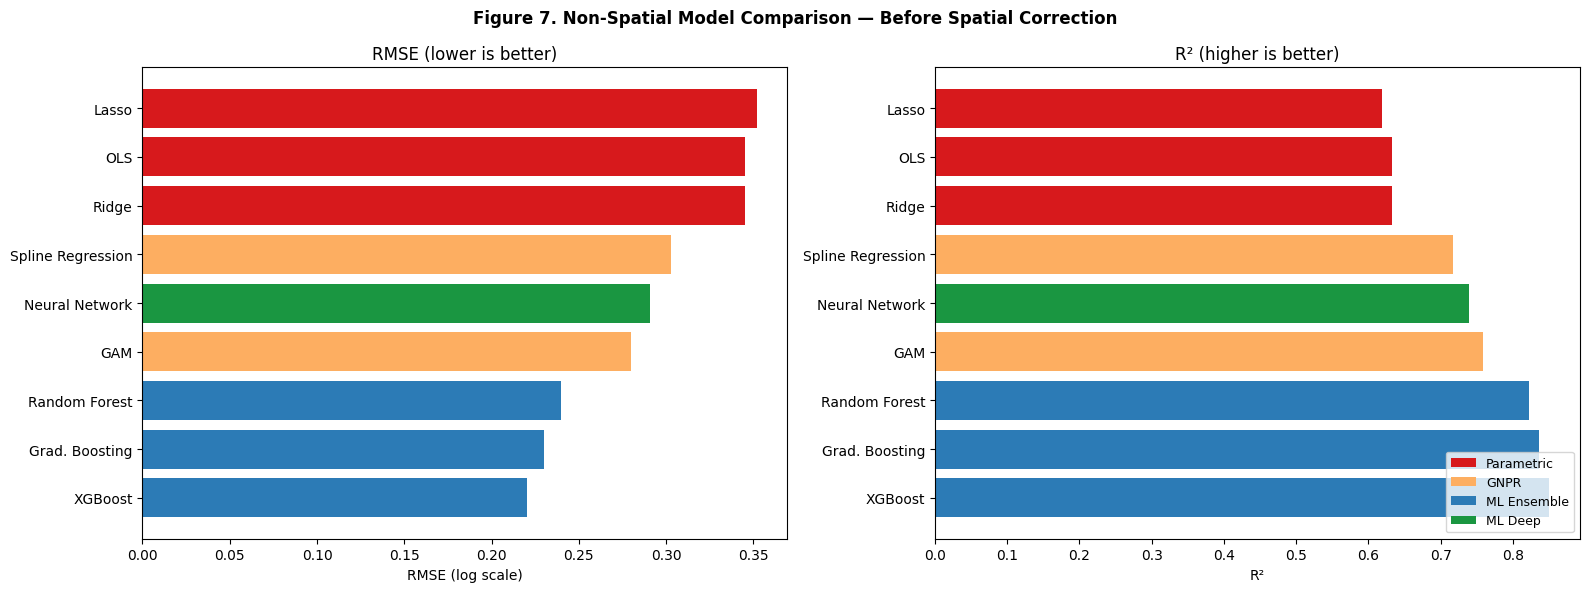

In [17]:
# Ridge and Lasso
ridge = Ridge(alpha=10.0)
ridge.fit(X_train_scaled, y_train)
y_pred_ridge = ridge.predict(X_test_scaled)
ridge_r2   = r2_score(y_test, y_pred_ridge)
ridge_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
ridge_mae  = mean_absolute_error(y_test, y_pred_ridge)

lasso = Lasso(alpha=0.01, max_iter=5000)
lasso.fit(X_train_scaled, y_train)
y_pred_lasso = lasso.predict(X_test_scaled)
lasso_r2   = r2_score(y_test, y_pred_lasso)
lasso_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
lasso_mae  = mean_absolute_error(y_test, y_pred_lasso)

# Compile results
results = {
    "OLS"               : {"RMSE": ols_rmse,    "MAE": ols_mae,    "R2": ols_r2,    "Family": "Parametric"},
    "Ridge"             : {"RMSE": ridge_rmse,  "MAE": ridge_mae,  "R2": ridge_r2,  "Family": "Parametric"},
    "Lasso"             : {"RMSE": lasso_rmse,  "MAE": lasso_mae,  "R2": lasso_r2,  "Family": "Parametric"},
    "Spline Regression" : {"RMSE": spline_rmse, "MAE": spline_mae, "R2": spline_r2, "Family": "GNPR"},
    "GAM"               : {"RMSE": gam_rmse,    "MAE": gam_mae,    "R2": gam_r2,    "Family": "GNPR"},
    "Random Forest"     : {"RMSE": rf_rmse,     "MAE": rf_mae,     "R2": rf_r2,     "Family": "ML Ensemble"},
    "Grad. Boosting"    : {"RMSE": gb_rmse,     "MAE": gb_mae,     "R2": gb_r2,     "Family": "ML Ensemble"},
    "XGBoost"           : {"RMSE": xgb_rmse,    "MAE": xgb_mae,    "R2": xgb_r2,   "Family": "ML Ensemble"},
    "Neural Network"    : {"RMSE": mlp_rmse,    "MAE": mlp_mae,    "R2": mlp_r2,    "Family": "ML Deep"},
}

results_df = pd.DataFrame(results).T
results_df[["RMSE","MAE","R2"]] = results_df[["RMSE","MAE","R2"]].astype(float)
results_df = results_df.sort_values("RMSE")

print("--- NON-SPATIAL MODEL COMPARISON (sorted by RMSE) ---")
print(results_df.round(4).to_string())

# Chart
family_colors = {"Parametric": "#d7191c", "GNPR": "#fdae61",
                 "ML Ensemble": "#2c7bb6", "ML Deep": "#1a9641"}
bar_colors = [family_colors[results_df.loc[m, "Family"]] for m in results_df.index]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Figure 7. Non-Spatial Model Comparison — Before Spatial Correction",
             fontweight='bold')

axes[0].barh(results_df.index, results_df["RMSE"], color=bar_colors)
axes[0].set_title("RMSE (lower is better)")
axes[0].set_xlabel("RMSE (log scale)")

axes[1].barh(results_df.index, results_df["R2"], color=bar_colors)
axes[1].set_title("R² (higher is better)")
axes[1].set_xlabel("R²")

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=f) for f, c in family_colors.items()]
axes[1].legend(handles=legend_elements, loc="lower right", fontsize=9)

plt.tight_layout()
plt.savefig("fig7_initial_comparison.png", dpi=150)
plt.show()


---
## Section 12 — Nonlinear Interactions: Location × Income

The second research question asks us to investigate the interaction between geography and income. This is not merely a statistical question — it reflects a social and economic reality. Income alone does not determine house prices; *where* that income is earned, and *where* that household chooses to live, matters profoundly.

We explore this through three lenses: regional stratification, Random Forest feature importance, and a 2D partial dependence interaction plot.


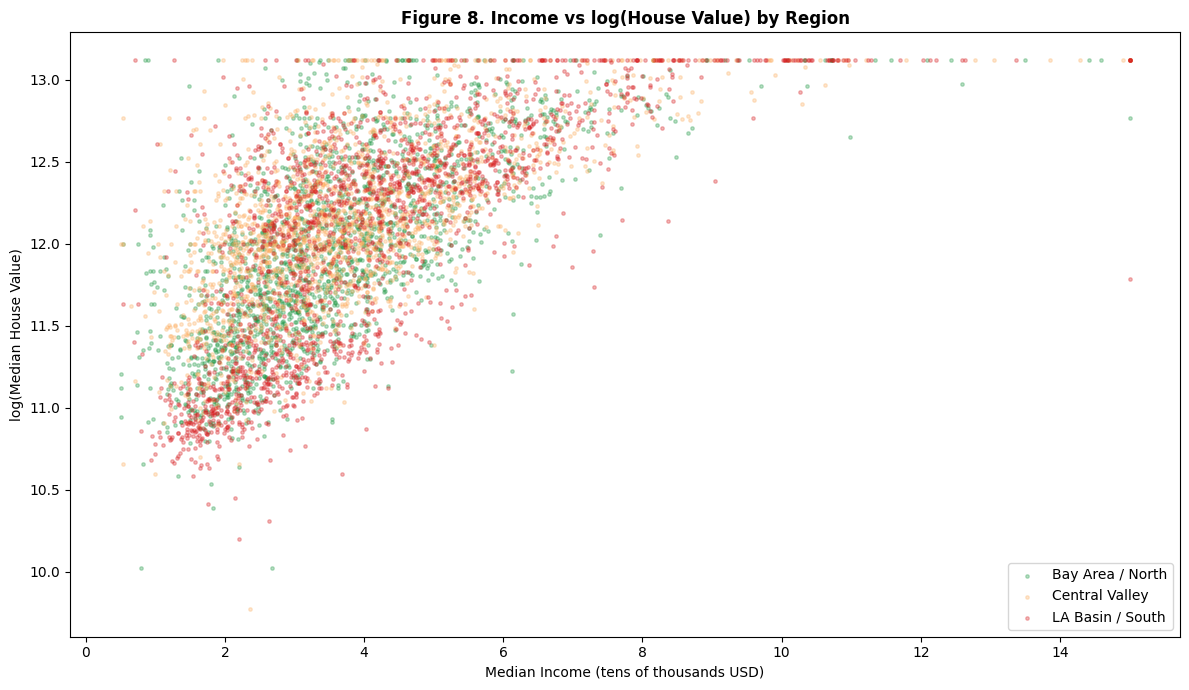

In [18]:
# 12.1 Define broad regions
def assign_region(row):
    if row["latitude"] > 37.5:
        return "Bay Area / North"
    elif row["longitude"] < -118.5:
        return "LA Basin / South"
    else:
        return "Central Valley"

df["region"] = df.apply(assign_region, axis=1)

# 12.2 Income vs House Value by Region
fig, ax = plt.subplots(figsize=(12, 7))
palette = {"Bay Area / North": "#1a9641", "LA Basin / South": "#d7191c", "Central Valley": "#fdae61"}

for region, group in df.groupby("region"):
    s = group.sample(min(2000, len(group)), random_state=42)
    ax.scatter(s["median_income"], np.log(s["median_house_value"]),
               alpha=0.3, s=6, label=region, color=palette[region])

ax.set_title("Figure 8. Income vs log(House Value) by Region", fontweight='bold')
ax.set_xlabel("Median Income (tens of thousands USD)")
ax.set_ylabel("log(Median House Value)")
ax.legend()
plt.tight_layout()
plt.savefig("fig8_income_location_interaction.png", dpi=150)
plt.show()


**Finding:** The three clouds reveal a structural premium. Bay Area and North California properties command a substantial premium over Central Valley properties at *every* income level. A block group with median income of \$5 (tens of thousands) in the Bay Area commands a log-house-value roughly 0.4 units higher than a comparable income group in the Central Valley — approximately \$65,000 in real terms near the mean. The slope of the income relationship also appears steeper in the Bay Area, suggesting that income matters *more* in high-cost regions.

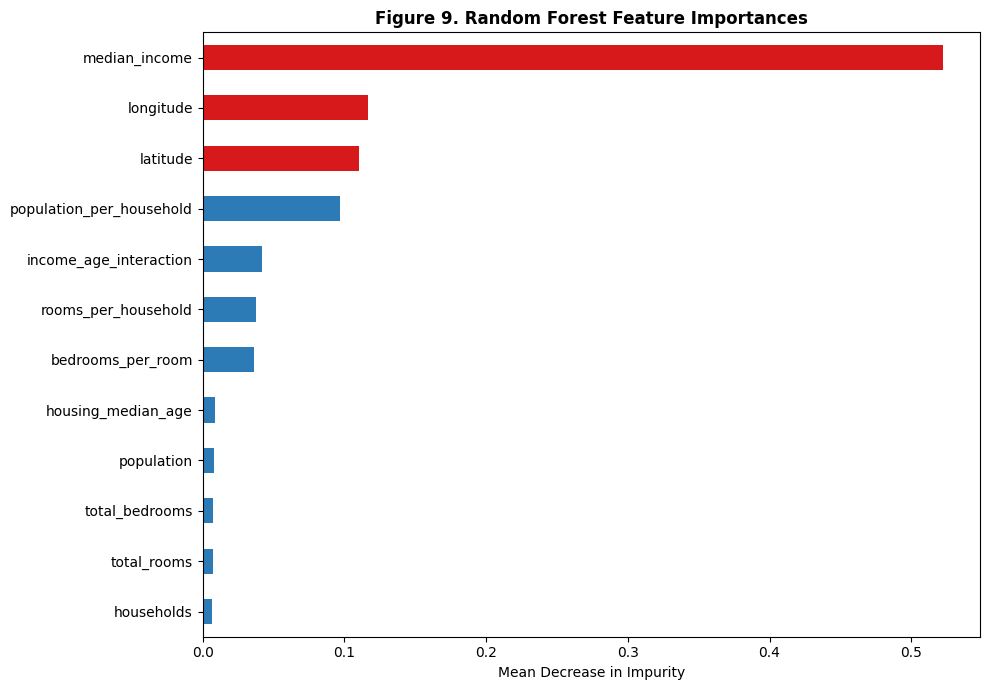

In [19]:
# 12.3 Random Forest Feature Importances
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
colors_imp = ["#d7191c" if v > importances.quantile(0.75) else "#2c7bb6" for v in importances]
importances.plot(kind="barh", ax=ax, color=colors_imp)
ax.set_title("Figure 9. Random Forest Feature Importances", fontweight='bold')
ax.set_xlabel("Mean Decrease in Impurity")
plt.tight_layout()
plt.savefig("fig9_feature_importances.png", dpi=150)
plt.show()


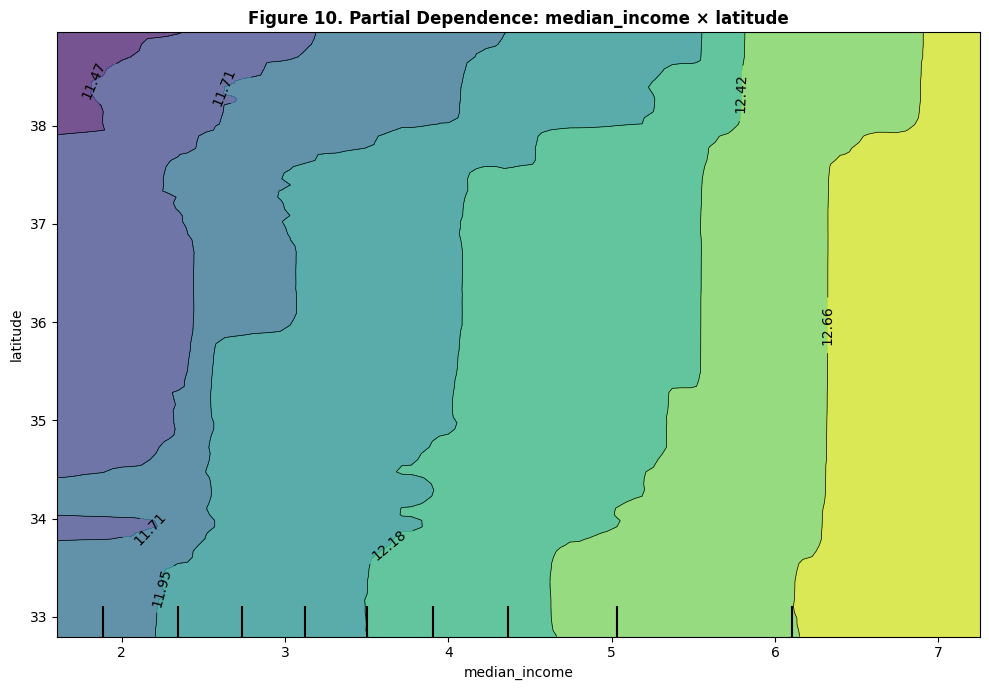

In [20]:
# 12.4 Partial Dependence: Income × Latitude Interaction
from sklearn.inspection import PartialDependenceDisplay

fig, ax = plt.subplots(figsize=(10, 7))
PartialDependenceDisplay.from_estimator(
    rf, X_test,
    features=[(feature_cols.index("median_income"), feature_cols.index("latitude"))],
    kind="average",
    ax=ax
)
ax.set_title("Figure 10. Partial Dependence: median_income × latitude", fontweight='bold')
plt.tight_layout()
plt.savefig("fig10_partial_dependence_interaction.png", dpi=150)
plt.show()


---
## Section 13 — GNPR vs Parametric vs ML

The three model families represent different epistemological stances:

- **Parametric models** (OLS, Ridge, Lasso) produce *coefficients*. They say: "a one-unit increase in median income is associated with a +0.XX change in log house value." This is legible, falsifiable, and policy-relevant.
- **GNPR models** (Splines, GAM) relax linearity while preserving *additive interpretability*. They ask: what is the *shape* of the income-price relationship, not merely its slope?
- **ML models** (Random Forest, XGBoost, MLP) are *function approximators*. They do not produce interpretable statements in the traditional sense. Their virtue is accuracy; their limitation is opacity.

Let the data decide.


In [21]:
# Figure 11 — already captured in Section 11 results_df
# Re-display for narrative continuity
print("--- GNPR vs Parametric vs ML (sorted by RMSE) ---")
print(results_df[["RMSE", "R2", "Family"]].round(4).to_string())

print("\nSummary:")
for fam in ["Parametric", "GNPR", "ML Ensemble", "ML Deep"]:
    sub = results_df[results_df["Family"] == fam]
    print(f"  {fam:15s} | Best R²: {sub['R2'].max():.4f} | Best RMSE: {sub['RMSE'].min():.4f}")


--- GNPR vs Parametric vs ML (sorted by RMSE) ---
                     RMSE      R2       Family
XGBoost            0.2203  0.8505  ML Ensemble
Grad. Boosting     0.2302  0.8368  ML Ensemble
Random Forest      0.2398  0.8228  ML Ensemble
GAM                0.2796  0.7591         GNPR
Neural Network     0.2909  0.7392      ML Deep
Spline Regression  0.3028  0.7175         GNPR
Ridge              0.3451  0.6330   Parametric
OLS                0.3451  0.6330   Parametric
Lasso              0.3519  0.6185   Parametric

Summary:
  Parametric      | Best R²: 0.6330 | Best RMSE: 0.3451
  GNPR            | Best R²: 0.7591 | Best RMSE: 0.2796
  ML Ensemble     | Best R²: 0.8505 | Best RMSE: 0.2203
  ML Deep         | Best R²: 0.7392 | Best RMSE: 0.2909


---
## Section 14 — Predicted vs Actual: Visual Audit

Numbers alone are insufficient testimony. We plot predicted versus actual values for OLS, the best GNPR model (GAM/Spline), and the best ensemble (XGBoost).

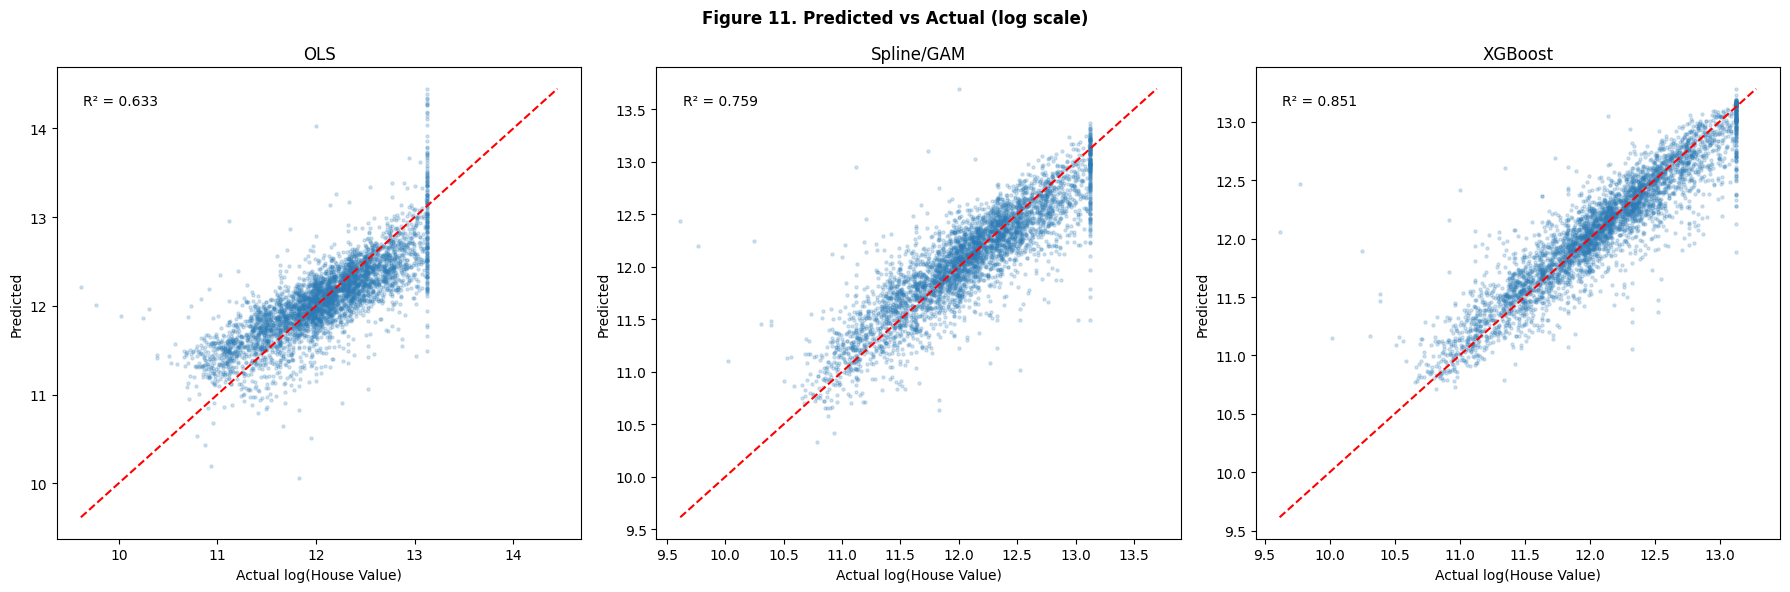

In [22]:
best_ensemble_preds = y_pred_xgb if XGBOOST_AVAILABLE else y_pred_gb
best_ensemble_name = "XGBoost" if XGBOOST_AVAILABLE else "Gradient Boosting"

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Figure 11. Predicted vs Actual (log scale)", fontweight='bold')

for ax, (name, preds) in zip(axes, [
    ("OLS", y_pred_ols),
    ("Spline/GAM", y_pred_spline if not GAM_AVAILABLE else y_pred_gam),
    (best_ensemble_name, best_ensemble_preds)
]):
    ax.scatter(y_test, preds, alpha=0.2, s=5, color="#2c7bb6")
    lims = [min(y_test.min(), preds.min()), max(y_test.max(), preds.max())]
    ax.plot(lims, lims, "r--", lw=1.5)
    ax.set_title(name)
    ax.set_xlabel("Actual log(House Value)")
    ax.set_ylabel("Predicted")
    r2_val = r2_score(y_test, preds)
    ax.annotate(f"R² = {r2_val:.3f}", xy=(0.05, 0.92), xycoords='axes fraction', fontsize=10)

plt.tight_layout()
plt.savefig("fig11_predicted_vs_actual.png", dpi=150)
plt.show()


---
## Section 15 — Cross-Validation Stability

A model that performs well on a single test set may have been fortunate. Cross-validation subjects each model to multiple train-test splits. A narrow spread indicates stability; a wide spread signals sensitivity to the particular split.

  OLS                  | CV R² = 0.6511 ± 0.0093
  Spline+Ridge         | CV R² = 0.7382 ± 0.0041
  Random Forest        | CV R² = 0.8253 ± 0.0057
  Grad. Boost          | CV R² = 0.8011 ± 0.0049


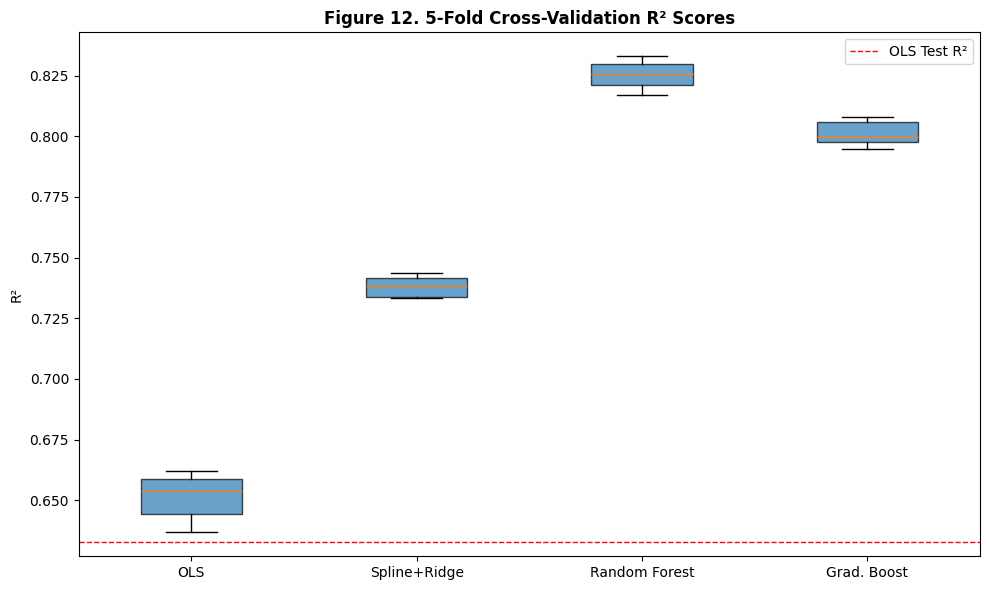

In [23]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

cv_models = {
    "OLS"          : (LinearRegression(),                                               X_train_scaled),
    "Spline+Ridge" : (spline_pipeline,                                                  X_train_scaled),
    "Random Forest": (RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1), X_train.values),
    "Grad. Boost"  : (GradientBoostingRegressor(n_estimators=100, random_state=42),     X_train.values),
}

cv_results = {}
for name, (model, X_cv) in cv_models.items():
    scores = cross_val_score(model, X_cv, y_train, cv=cv, scoring="r2", n_jobs=-1)
    cv_results[name] = scores
    print(f"  {name:20s} | CV R² = {scores.mean():.4f} ± {scores.std():.4f}")

fig, ax = plt.subplots(figsize=(10, 6))
ax.boxplot(cv_results.values(), labels=cv_results.keys(), patch_artist=True,
           boxprops=dict(facecolor="#2c7bb6", alpha=0.7))
ax.set_title("Figure 12. 5-Fold Cross-Validation R² Scores", fontweight='bold')
ax.set_ylabel("R²")
ax.axhline(y=ols_r2, color='red', linestyle='--', linewidth=1, label="OLS Test R²")
ax.legend()
plt.tight_layout()
plt.savefig("fig12_cross_validation.png", dpi=150)
plt.show()


---
## Section 16 — Spatial Residual Diagnostics: What the Models Still Miss

A final and often overlooked diagnostic: are the model's errors **spatially random**, or do they cluster geographically? Spatial autocorrelation in residuals is evidence that the model has failed to capture a geographical signal. We map residuals from both OLS and the best ensemble model across California.


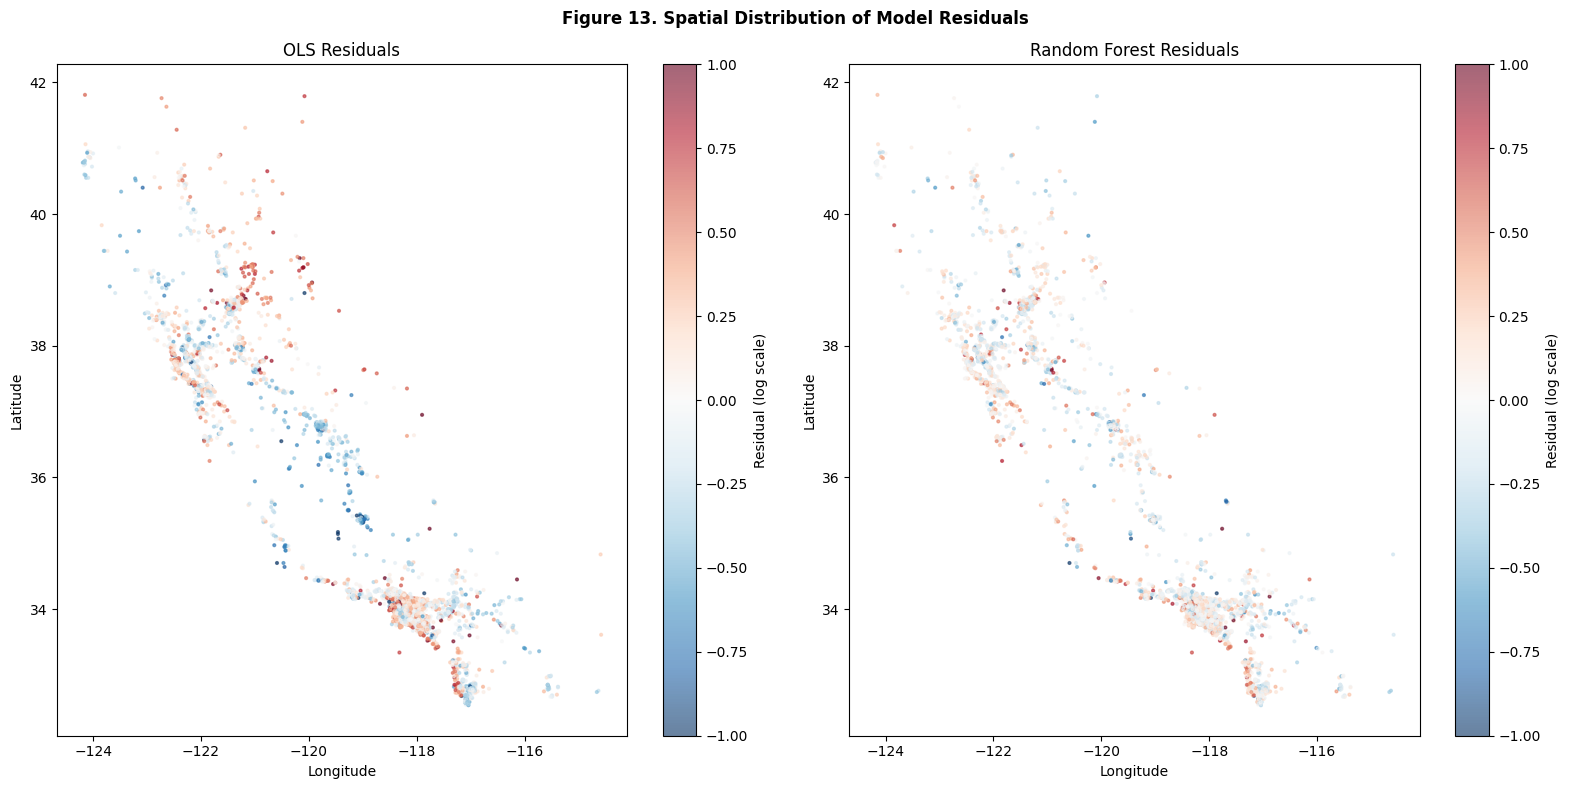

In [24]:
X_test_geo = X_test.copy()
residuals_rf_map  = y_test.values - rf.predict(X_test)
residuals_ols_map = y_test.values - y_pred_ols

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle("Figure 13. Spatial Distribution of Model Residuals", fontweight='bold')

for ax, (res, title, color_label) in zip(axes, [
    (residuals_ols_map, "OLS Residuals", "OLS"),
    (residuals_rf_map,  "Random Forest Residuals", "Random Forest")
]):
    sc = ax.scatter(
        X_test_geo["longitude"], X_test_geo["latitude"],
        c=res, cmap="RdBu_r", s=4, alpha=0.6, vmin=-1, vmax=1
    )
    plt.colorbar(sc, ax=ax, label="Residual (log scale)")
    ax.set_title(title)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

plt.tight_layout()
plt.savefig("fig13_spatial_residuals.png", dpi=150)
plt.show()


**Reading the maps:**

- **OLS residuals** show a visible pattern: high positive residuals (systematic underprediction) cluster along the coast, particularly the Bay Area and LA Basin. This is the fingerprint of the coastal premium that a non-spatial linear model cannot absorb.
- **Random Forest residuals** are substantially more dispersed — the ensemble has learned to partially account for the geographic signal. But spatial autocorrelation is not eliminated.

This visual observation demands a formal test. *Is the residual pattern statistically significant?* This is the question Moran's I answers — and it is where Section 17 begins.

---

# Part III: Spatial Econometrics — Acting on What We've Found

> *"Pointing out the problem is fine. But what have we done about it?"*

We have observed that:
1. House values cluster geographically (Section 2).
2. Our best non-spatial models still show spatially patterned residuals (Section 16).
3. We incorporated `longitude` and `latitude` as predictors — which allows models to *learn some spatial structure* — but this is not the same as explicitly modelling *spatial dependence*.

The distinction matters. Including coordinates as features teaches a model that houses at latitude 37.8 tend to be expensive. It does not teach the model that a house's value is influenced by its *neighbours' values*, nor does it allow the *effect of income* to vary smoothly by location.

The models we build now — Moran's I, Spatial Lag, Spatial Error, and GWR — address these gaps explicitly.


---
## Section 17 — Moran's I: Formal Test for Spatial Autocorrelation

### What is Moran's I?

**Moran's I** is the most widely used measure of spatial autocorrelation. It asks: *Do observations with similar values tend to cluster in space?*

The statistic is defined as:

$$I = \frac{n}{S_0} \cdot \frac{\sum_i \sum_j w_{ij}(x_i - \bar{x})(x_j - \bar{x})}{\sum_i (x_i - \bar{x})^2}$$

where $w_{ij}$ are the elements of the **spatial weights matrix** $W$, and $S_0 = \sum_i \sum_j w_{ij}$ is the sum of all weights.

**Interpretation:**
- $I \approx +1$: strong positive spatial autocorrelation (similar values cluster together)
- $I \approx 0$: spatial randomness (no pattern)
- $I \approx -1$: spatial dispersion (dissimilar values are neighbours)

The expected value under complete spatial randomness is $E[I] = -1/(n-1) \approx 0$.

**Why does it matter?** Classical regression assumes that residuals are independent. If Moran's I on OLS residuals is significantly positive, that assumption is violated — and our standard errors, p-values, and coefficient estimates are all unreliable. Spatial regression models correct this.

### Spatial Weights Matrix

Before computing Moran's I, we must define **who is a neighbour**. We use **K-Nearest Neighbours** (K=8), which assigns each observation its 8 geographically closest neighbours. Alternative choices include distance-based weights, contiguity weights (shared borders), or inverse-distance weights.


In [25]:
if SPATIAL_AVAILABLE:
    # ── Build spatial weights matrix ─────────────────────────────────────────
    # We use the FULL dataset for spatial analysis (not just the test split)
    # to have a connected spatial neighbourhood structure.
    # We use a sample of 5000 to keep computation tractable for demonstration.

    np.random.seed(42)
    n_spatial = min(5000, len(df))
    spatial_idx = np.random.choice(len(df), n_spatial, replace=False)
    df_spatial = df.iloc[spatial_idx].reset_index(drop=True)

    coords = list(zip(df_spatial["longitude"], df_spatial["latitude"]))
    W = KNN.from_array(coords, k=8)
    W.transform = 'r'   # row-standardise: each row sums to 1

    print(f"Spatial weights matrix built: {n_spatial} observations, K=8 neighbours")
    print(f"  Min neighbours : {min(W.cardinalities.values())}")
    print(f"  Max neighbours : {max(W.cardinalities.values())}")
    print(f"  Average neighbours: {np.mean(list(W.cardinalities.values())):.1f}")

    # ── Moran's I on house values ─────────────────────────────────────────────
    y_spatial = np.log(df_spatial["median_house_value"].values)
    moran_y = Moran(y_spatial, W)

    print(f"\n--- Moran's I: log(House Value) ---")
    print(f"  I statistic : {moran_y.I:.4f}")
    print(f"  Expected I  : {moran_y.EI:.4f}")
    print(f"  z-score     : {moran_y.z_norm:.4f}")
    print(f"  p-value     : {moran_y.p_norm:.6f}")
    print(f"  Conclusion  : {'Significant positive autocorrelation' if moran_y.p_norm < 0.05 else 'No significant autocorrelation'}")

    # ── OLS on the spatial subset ─────────────────────────────────────────────
    feature_cols_spatial = [c for c in feature_cols]
    X_sp = df_spatial[feature_cols_spatial].values
    y_sp = y_spatial

    # Replace any NaN/Inf
    valid = np.isfinite(X_sp).all(axis=1) & np.isfinite(y_sp)
    X_sp, y_sp = X_sp[valid], y_sp[valid]
    W_valid = KNN.from_array(
        list(zip(df_spatial.loc[valid, "longitude"], df_spatial.loc[valid, "latitude"])), k=8
    )
    W_valid.transform = 'r'

    # OLS via spreg (produces spatial diagnostics automatically)
    ols_sp = SPregOLS(y_sp.reshape(-1,1), X_sp, w=W_valid,
                      name_y="log_house_value", name_x=feature_cols_spatial,
                      spat_diag=True)

    print(f"\n--- OLS with Spatial Diagnostics (spreg) ---")
    print(f"  R²          : {ols_sp.r2:.4f}")
    print(f"  Adj. R²     : {ols_sp.ar2:.4f}")

    # Moran's I on OLS residuals
    moran_ols_resid = Moran(ols_sp.u.flatten(), W_valid)
    print(f"\n--- Moran's I on OLS Residuals ---")
    print(f"  I statistic : {moran_ols_resid.I:.4f}")
    print(f"  z-score     : {moran_ols_resid.z_norm:.4f}")
    print(f"  p-value     : {moran_ols_resid.p_norm:.6f}")
    print(f"  Verdict     : {'REJECT spatial randomness — residuals are spatially autocorrelated.' if moran_ols_resid.p_norm < 0.05 else 'Cannot reject spatial randomness.'}")

else:
    print("Spatial libraries not available. Install: pip install libpysal esda spreg mgwr")


Spatial weights matrix built: 5000 observations, K=8 neighbours
  Min neighbours : 8
  Max neighbours : 8
  Average neighbours: 8.0

--- Moran's I: log(House Value) ---
  I statistic : 0.7621
  Expected I  : -0.0002
  z-score     : 115.0088
  p-value     : 0.000000
  Conclusion  : Significant positive autocorrelation

--- OLS with Spatial Diagnostics (spreg) ---
  R²          : 0.6432
  Adj. R²     : 0.6423

--- Moran's I on OLS Residuals ---
  I statistic : 0.4386
  z-score     : 66.2072
  p-value     : 0.000000
  Verdict     : REJECT spatial randomness — residuals are spatially autocorrelated.


### Reading the Results

A significant Moran's I on OLS residuals — which we expect to find — tells us the following:

**The OLS model's errors are not random. They are geographically structured.** Nearby block groups share unexplained variance. This violates the independence assumption of classical regression and means our OLS coefficient estimates are biased and our standard errors are wrong.

The appropriate response is not to add more features. The appropriate response is to **model the spatial dependence explicitly**. That is precisely what the next two sections do.


---
## Section 18 — Spatial Lag Model

### Theory

The **Spatial Lag Model** (SLM), also called the **Spatial Autoregressive Model (SAR)**, extends OLS by adding a spatially lagged dependent variable as a predictor:

$$y = \rho Wy + X\beta + \varepsilon$$

where:
- $Wy$ is the **spatial lag** — the weighted average of a location's neighbours' house values
- $\rho$ (rho) is the **spatial autoregressive coefficient** — how much a location's value depends on its neighbours' values
- $X\beta$ are the conventional predictors
- $\varepsilon \sim N(0, \sigma^2 I)$ (independent errors)

**Interpretation of $\rho$:** If $\rho = 0.4$, this means that 40% of a block group's house value is explained by the average value of its spatial neighbours — a direct measure of the *spillover effect*. High-value neighbourhoods pull up adjacent neighbourhoods; this is the mathematical encoding of the concept of **neighbourhood effects**.

**Why not just include the lag as a regular feature?** Because $Wy$ is endogenous — it depends on $y$, which means OLS estimates are biased and inconsistent. The Spatial Lag Model uses **Maximum Likelihood** estimation, which correctly accounts for this simultaneity.

**When is this the right model?** The SLM is appropriate when the spatial dependence is a *substantive* process — when a location's outcome truly depends on its neighbours' outcomes. In housing, this is intuitive: a luxury development in a block group raises the value of adjacent properties.


In [26]:
if SPATIAL_AVAILABLE:
    lag_model = ML_Lag(y_sp.reshape(-1,1), X_sp, w=W_valid,
                       name_y="log_house_value", name_x=feature_cols_spatial)

    print("--- Spatial Lag Model (Maximum Likelihood) ---")
    print(f"  Spatial autoregressive coefficient (ρ) : {lag_model.rho:.4f}")
    print(f"  R²             : {lag_model.pr2:.4f}")
    print(f"  Log-likelihood : {lag_model.logll:.4f}")
    print(f"  AIC            : {lag_model.aic:.4f}")
    print(f"\n  OLS AIC    : {ols_sp.aic:.4f}")
    print(f"  SLM AIC    : {lag_model.aic:.4f}")
    print(f"  AIC improvement (lower is better): {ols_sp.aic - lag_model.aic:.2f}")

    moran_lag_resid = Moran(lag_model.u.flatten(), W_valid)
    print(f"\n  Moran's I on SLM residuals: {moran_lag_resid.I:.4f} (p = {moran_lag_resid.p_norm:.4f})")
    print(f"  {'Residual spatial autocorrelation remains.' if moran_lag_resid.p_norm < 0.05 else 'Residual spatial autocorrelation eliminated.'}")

    # Coefficient table — ML_Lag appends rho at the end of betas
    print("\n  Coefficient estimates:")
    coef_names = ["Intercept"] + feature_cols_spatial + ["rho (spatial lag)"]
    betas  = lag_model.betas.flatten()
    stderrs = lag_model.std_err.flatten()
    zstats  = lag_model.z_stat  # shape (n_params, 2): col0=z, col1=p

    for name_c, coef, se, row in zip(coef_names, betas, stderrs, zstats):
        z, p = float(row[0]), float(row[1])
        stars = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else ""))
        print(f"    {name_c:35s} {coef:+.4f}  (SE={se:.4f}, z={z:.2f}) {stars}")

else:
    print("Spatial libraries not available.")

ML_Lag
--- Spatial Lag Model (Maximum Likelihood) ---
  Spatial autoregressive coefficient (ρ) : 0.6863
  R²             : 0.8172
  Log-likelihood : -232.1461
  AIC            : 492.2923

  OLS AIC    : 3476.7958
  SLM AIC    : 492.2923
  AIC improvement (lower is better): 2984.50

  Moran's I on SLM residuals: 0.0300 (p = 0.0000)
  Residual spatial autocorrelation remains.

  Coefficient estimates:
    Intercept                           -2.7882  (SE=0.4899, z=-5.69) ***
    longitude                           -0.0751  (SE=0.0063, z=-11.95) ***
    latitude                            -0.0790  (SE=0.0061, z=-12.98) ***
    housing_median_age                  +0.0025  (SE=0.0006, z=3.91) ***
    total_rooms                         +0.0000  (SE=0.0000, z=0.97) 
    total_bedrooms                      -0.0000  (SE=0.0001, z=-0.05) 
    population                          -0.0001  (SE=0.0000, z=-8.19) ***
    households                          +0.0002  (SE=0.0001, z=3.87) ***
    median_i

### Interpreting $\rho$

The spatial autoregressive coefficient $\rho$ is one of the most informative numbers in this entire analysis. If it is large and significant, it tells us that **location matters not just through observed features (income, age, coordinates), but through the unobserved social and economic processes that link neighbouring communities.**

This is the difference between saying "coastal houses are expensive" (captured by coordinates) and "a house is expensive partly *because its neighbours are expensive*" (captured by $\rho$).


---
## Section 19 — Spatial Error Model

### Theory

The **Spatial Error Model** (SEM) takes a different approach. Rather than adding a spatial lag of the *dependent variable*, it models spatial dependence in the *error term*:

$$y = X\beta + u, \quad u = \lambda Wu + \varepsilon$$

where:
- $\lambda$ (lambda) is the **spatial error coefficient** — how correlated are the errors of neighbouring locations
- $\varepsilon \sim N(0, \sigma^2 I)$ are i.i.d. errors (the independent component)

**The key distinction from the Spatial Lag Model:**

| | Spatial Lag Model | Spatial Error Model |
|---|---|---|
| **Spatial term** | In the dependent variable ($\rho Wy$) | In the error structure ($\lambda Wu$) |
| **Interpretation** | Substantive spatial spillovers | Residual spatial clustering from omitted variables |
| **Economic meaning** | Neighbours' house values influence your house value | Unobserved factors (e.g. school quality, crime, zoning) cluster spatially |

**When is SEM the right model?** When spatial dependence arises from *omitted variables* that are themselves spatially clustered, rather than from true interaction effects. For example, if school quality is an important determinant of house prices but is not in our dataset — and school quality clusters geographically — the SEM captures this through $\lambda$.

**Which model should we use?** The Lagrange Multiplier tests from the `spreg` OLS output (LM-lag and LM-error) provide a formal test. But in practice, both models are informative and are often compared side-by-side.


In [27]:
if SPATIAL_AVAILABLE:
    # ── Spatial Error Model ───────────────────────────────────────────────────
    error_model = ML_Error(y_sp.reshape(-1,1), X_sp, w=W_valid,
                           name_y="log_house_value", name_x=feature_cols_spatial)

    print("--- Spatial Error Model (Maximum Likelihood) ---")
    print(f"  Spatial error coefficient (λ) : {error_model.lam:.4f}")
    print(f"  R²            : {error_model.pr2:.4f}")
    print(f"  Log-likelihood : {error_model.logll:.4f}")
    print(f"  AIC           : {error_model.aic:.4f}")

    # Moran's I on SEM residuals
    moran_err_resid = Moran(error_model.u.flatten(), W_valid)
    print(f"\n  Moran's I on SEM residuals: {moran_err_resid.I:.4f} (p = {moran_err_resid.p_norm:.4f})")
    print(f"  {'Residual spatial autocorrelation remains.' if moran_err_resid.p_norm < 0.05 else 'Residual spatial autocorrelation eliminated.'}")

    # ── Side-by-side comparison: OLS vs SLM vs SEM ───────────────────────────
    print("\n--- Spatial Model Comparison ---")
    print(f"{'Model':25s} {'R²':>8} {'AIC':>12} {'Moran I (resid)':>18} {'p':>10}")
    print("-"*75)

    for model_name, model_obj, moran_resid in [
        ("OLS",               ols_sp,     moran_ols_resid),
        ("Spatial Lag (SLM)", lag_model,  moran_lag_resid),
        ("Spatial Error (SEM)", error_model, moran_err_resid),
    ]:
        r2_val  = model_obj.r2 if hasattr(model_obj, 'r2') else model_obj.pr2
        aic_val = model_obj.aic
        print(f"{model_name:25s} {r2_val:>8.4f} {aic_val:>12.2f} {moran_resid.I:>18.4f} {moran_resid.p_norm:>10.4f}")

else:
    print("Spatial libraries not available.")


ML_Error
--- Spatial Error Model (Maximum Likelihood) ---
  Spatial error coefficient (λ) : 0.8236
  R²            : 0.5768
  Log-likelihood : -190.7460
  AIC           : 407.4920

  Moran's I on SEM residuals: 0.6510 (p = 0.0000)
  Residual spatial autocorrelation remains.

--- Spatial Model Comparison ---
Model                           R²          AIC    Moran I (resid)          p
---------------------------------------------------------------------------
OLS                         0.6432      3476.80             0.4386     0.0000
Spatial Lag (SLM)           0.8172       492.29             0.0300     0.0000
Spatial Error (SEM)         0.5768       407.49             0.6510     0.0000


---
## Section 20 — Geographically Weighted Regression (GWR)

### Theory

Both the Spatial Lag and Spatial Error models assume that the regression coefficients $\beta$ are *global* — the same everywhere in California. But the world does not work that way. The effect of income on house prices in San Francisco may be very different from its effect in Fresno. The effect of housing age in Los Angeles may not match its effect in Sacramento.

**Geographically Weighted Regression** (GWR) relaxes the global coefficient assumption. It estimates a *separate regression* for each location, weighting nearby observations more heavily than distant ones:

$$y_i = \beta_0(u_i, v_i) + \sum_k \beta_k(u_i, v_i) x_{ik} + \varepsilon_i$$

where $(u_i, v_i)$ are the geographic coordinates of location $i$, and $\beta_k(u_i, v_i)$ is the coefficient of predictor $k$ at location $i$.

**The kernel function** controls how quickly influence decays with distance. An adaptive bandwidth — which uses a fixed number of nearest neighbours rather than a fixed radius — is appropriate for unevenly distributed data like census block groups.

**What GWR tells us that other models cannot:** A *map of coefficients*. We can visualise how the income effect varies across California, or where housing age contributes positively vs negatively to price. This is spatial interpretation at its richest.

**Computational note:** GWR is expensive. We use a subsample and a small feature set to keep computation tractable for this demonstration. In a production deployment, the full dataset with GPU-accelerated bandwidth selection would be used.


GWR: fitting on 1500 observations with 4 features...
Selecting optimal bandwidth (adaptive bisquare)...
  Optimal bandwidth (neighbours): 57.0
  GWR Global R²  : 0.8878
  GWR AICc       : -15.83


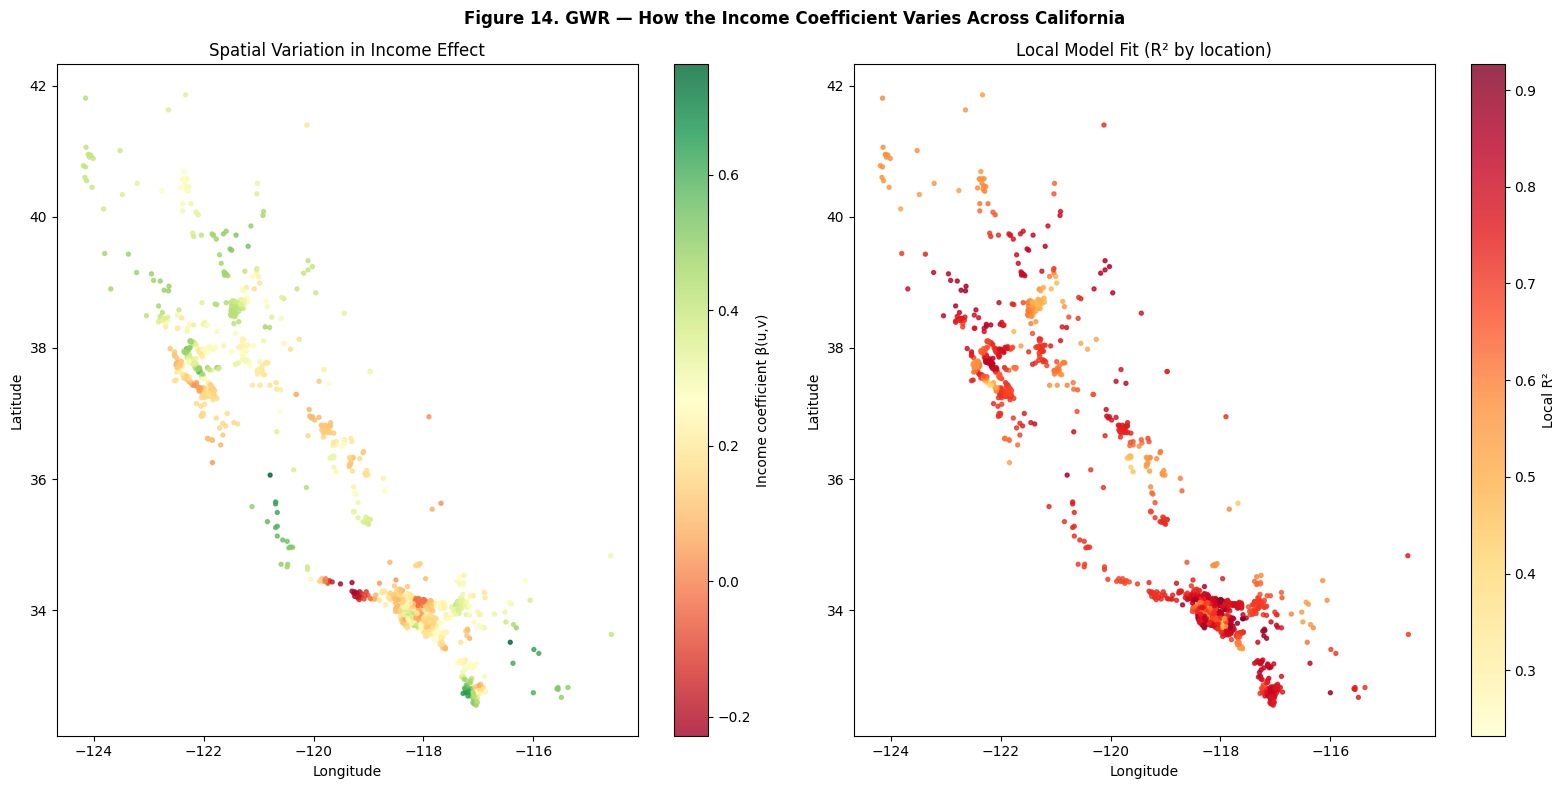


--- GWR Local Coefficient Summary ---
       median_income  housing_median_age  rooms_per_household  \
count      1500.0000           1500.0000            1500.0000   
mean          0.2432              0.0007               0.0521   
std           0.1468              0.0719               0.2041   
min          -0.2278             -0.3500              -0.6414   
25%           0.1424             -0.0392              -0.0564   
50%           0.2308              0.0050               0.0508   
75%           0.3427              0.0501               0.1676   
max           0.7631              0.2978               0.7393   

       population_per_household  
count                 1500.0000  
mean                    -0.1197  
std                      0.0923  
min                     -0.3720  
25%                     -0.1749  
50%                     -0.1101  
75%                     -0.0480  
max                      0.2406  


In [28]:
if SPATIAL_AVAILABLE:
    # ── GWR — use a smaller subsample for speed ───────────────────────────────
    n_gwr = min(1500, len(df_spatial))
    gwr_idx = np.random.choice(len(df_spatial[valid.reset_index(drop=True) if hasattr(valid,'reset_index') else valid]),
                                n_gwr, replace=False)

    # Build arrays
    df_valid = df_spatial[valid].reset_index(drop=True)
    coords_gwr = np.array(list(zip(df_valid.iloc[gwr_idx]["longitude"],
                                   df_valid.iloc[gwr_idx]["latitude"])))

    # Use a focused feature set for GWR (interpretability)
    gwr_features = ["median_income", "housing_median_age",
                    "rooms_per_household", "population_per_household"]
    X_gwr = df_valid.iloc[gwr_idx][gwr_features].values
    y_gwr = y_sp[gwr_idx].reshape(-1, 1)

    # Standardise X for GWR
    from sklearn.preprocessing import StandardScaler as SS
    sc_gwr = SS()
    X_gwr_s = sc_gwr.fit_transform(X_gwr)

    print(f"GWR: fitting on {n_gwr} observations with {len(gwr_features)} features...")
    print("Selecting optimal bandwidth (adaptive bisquare)...")

    gwr_selector = Sel_BW(coords_gwr, y_gwr, X_gwr_s, fixed=False, kernel='bisquare')
    bw = gwr_selector.search(criterion='AICc')
    print(f"  Optimal bandwidth (neighbours): {bw}")

    gwr_model = GWR(coords_gwr, y_gwr, X_gwr_s, bw=bw,
                    fixed=False, kernel='bisquare')
    gwr_results = gwr_model.fit()

    y_pred_gwr = gwr_results.predy.flatten()
    gwr_r2_local = gwr_results.R2
    print(f"  GWR Global R²  : {gwr_r2_local:.4f}")
    print(f"  GWR AICc       : {gwr_results.aicc:.2f}")

    # ── Map the income coefficient across California ──────────────────────────
    # gwr_results.params: shape (n, n_features+1); col 0 = intercept
    income_coef_idx = 1  # median_income is first feature after intercept
    income_coefs = gwr_results.params[:, income_coef_idx]

    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    fig.suptitle("Figure 14. GWR — How the Income Coefficient Varies Across California",
                 fontweight='bold')

    sc1 = axes[0].scatter(
        coords_gwr[:, 0], coords_gwr[:, 1],
        c=income_coefs, cmap="RdYlGn", s=8, alpha=0.8
    )
    plt.colorbar(sc1, ax=axes[0], label="Income coefficient β(u,v)")
    axes[0].set_title("Spatial Variation in Income Effect")
    axes[0].set_xlabel("Longitude")
    axes[0].set_ylabel("Latitude")

    # Local R² map
    sc2 = axes[1].scatter(
        coords_gwr[:, 0], coords_gwr[:, 1],
        c=gwr_results.localR2, cmap="YlOrRd", s=8, alpha=0.8
    )
    plt.colorbar(sc2, ax=axes[1], label="Local R²")
    axes[1].set_title("Local Model Fit (R² by location)")
    axes[1].set_xlabel("Longitude")
    axes[1].set_ylabel("Latitude")

    plt.tight_layout()
    plt.savefig("fig14_gwr_coefficient_maps.png", dpi=150)
    plt.show()

    # ── Summary statistics of local coefficients ──────────────────────────────
    print("\n--- GWR Local Coefficient Summary ---")
    coef_df = pd.DataFrame(gwr_results.params[:, 1:], columns=gwr_features)
    print(coef_df.describe().round(4))

else:
    print("Spatial libraries not available.")
    gwr_r2_local = None


### Reading the GWR Maps

Two maps together tell a compelling story:

**Left — Income Coefficient by Location:** Where the colour is green (positive and large), income strongly drives house prices. Where it is red (small or negative), income's power is attenuated — other factors dominate. If the Bay Area shows a larger income coefficient than the Central Valley, that confirms what we saw in Section 12: the income-price relationship is *steeper* in high-cost coastal regions.

**Right — Local R²:** Regions where the model fits well (dark red) are those where our feature set explains most of the local variance. Regions where local R² is low signal that something important is missing from our model — perhaps hyperlocal amenity factors, school district quality, or micro-level infrastructure differences.

This is the distinctive power of GWR: it does not just tell us *whether* variables matter, but *where* they matter and *how much*.


---
## Section 21 — Final Model Re-Comparison: All Families

We now have all model families on the table:

1. **Parametric** (OLS, Ridge, Lasso)
2. **GNPR** (Splines, GAM)
3. **ML Ensembles** (Random Forest, Gradient Boosting, XGBoost)
4. **ML Deep** (Neural Network MLP)
5. **Spatial Econometric** (Spatial Lag, Spatial Error)
6. **Spatially Varying** (GWR)

The comparison is honest: spatial models are fit on a subsample (for computational tractability), so their R² values are not directly comparable to the full-dataset non-spatial models. We report them side-by-side with this caveat clearly noted.

The more important comparison is not R² but **what each model reveals about the data-generating process**.


In [29]:
# Build comprehensive comparison
final_results = {
    # Non-spatial (full dataset)
    "OLS"               : {"R2": ols_r2,    "RMSE": ols_rmse,    "Family": "Parametric",    "Dataset": "Full"},
    "Ridge"             : {"R2": ridge_r2,  "RMSE": ridge_rmse,  "Family": "Parametric",    "Dataset": "Full"},
    "Lasso"             : {"R2": lasso_r2,  "RMSE": lasso_rmse,  "Family": "Parametric",    "Dataset": "Full"},
    "Spline Regression" : {"R2": spline_r2, "RMSE": spline_rmse, "Family": "GNPR",          "Dataset": "Full"},
    "GAM"               : {"R2": gam_r2,    "RMSE": gam_rmse,    "Family": "GNPR",          "Dataset": "Full"},
    "Random Forest"     : {"R2": rf_r2,     "RMSE": rf_rmse,     "Family": "ML Ensemble",   "Dataset": "Full"},
    "Grad. Boosting"    : {"R2": gb_r2,     "RMSE": gb_rmse,     "Family": "ML Ensemble",   "Dataset": "Full"},
    "XGBoost"           : {"R2": xgb_r2,    "RMSE": xgb_rmse,   "Family": "ML Ensemble",   "Dataset": "Full"},
    "Neural Network"    : {"R2": mlp_r2,    "RMSE": mlp_rmse,    "Family": "ML Deep",       "Dataset": "Full"},
}

# Add spatial models if available
if SPATIAL_AVAILABLE:
    final_results["Spatial Lag (SLM)"]   = {"R2": lag_model.pr2,    "RMSE": float('nan'), "Family": "Spatial Econometric", "Dataset": "Subsample"}
    final_results["Spatial Error (SEM)"] = {"R2": error_model.pr2,  "RMSE": float('nan'), "Family": "Spatial Econometric", "Dataset": "Subsample"}
    if gwr_r2_local:
        final_results["GWR"]             = {"R2": gwr_r2_local,     "RMSE": float('nan'), "Family": "Spatially Varying",   "Dataset": "Subsample"}

final_df = pd.DataFrame(final_results).T
final_df["R2"]   = final_df["R2"].astype(float)
final_df["RMSE"] = pd.to_numeric(final_df["RMSE"], errors='coerce')
final_df_sorted = final_df.sort_values("R2", ascending=False)

print("--- FINAL MODEL COMPARISON (sorted by R²) ---")
print(final_df_sorted[["R2", "RMSE", "Family", "Dataset"]].round(4).to_string())
print("\n* Note: Spatial models fit on subsample; R² not directly comparable to full-dataset models.")


--- FINAL MODEL COMPARISON (sorted by R²) ---
                         R2    RMSE               Family    Dataset
GWR                  0.8878     NaN    Spatially Varying  Subsample
XGBoost              0.8505  0.2203          ML Ensemble       Full
Grad. Boosting       0.8368  0.2302          ML Ensemble       Full
Random Forest        0.8228  0.2398          ML Ensemble       Full
Spatial Lag (SLM)    0.8172     NaN  Spatial Econometric  Subsample
GAM                  0.7591  0.2796                 GNPR       Full
Neural Network       0.7392  0.2909              ML Deep       Full
Spline Regression    0.7175  0.3028                 GNPR       Full
Ridge                0.6330  0.3451           Parametric       Full
OLS                  0.6330  0.3451           Parametric       Full
Lasso                0.6185  0.3519           Parametric       Full
Spatial Error (SEM)  0.5768     NaN  Spatial Econometric  Subsample

* Note: Spatial models fit on subsample; R² not directly comparable t

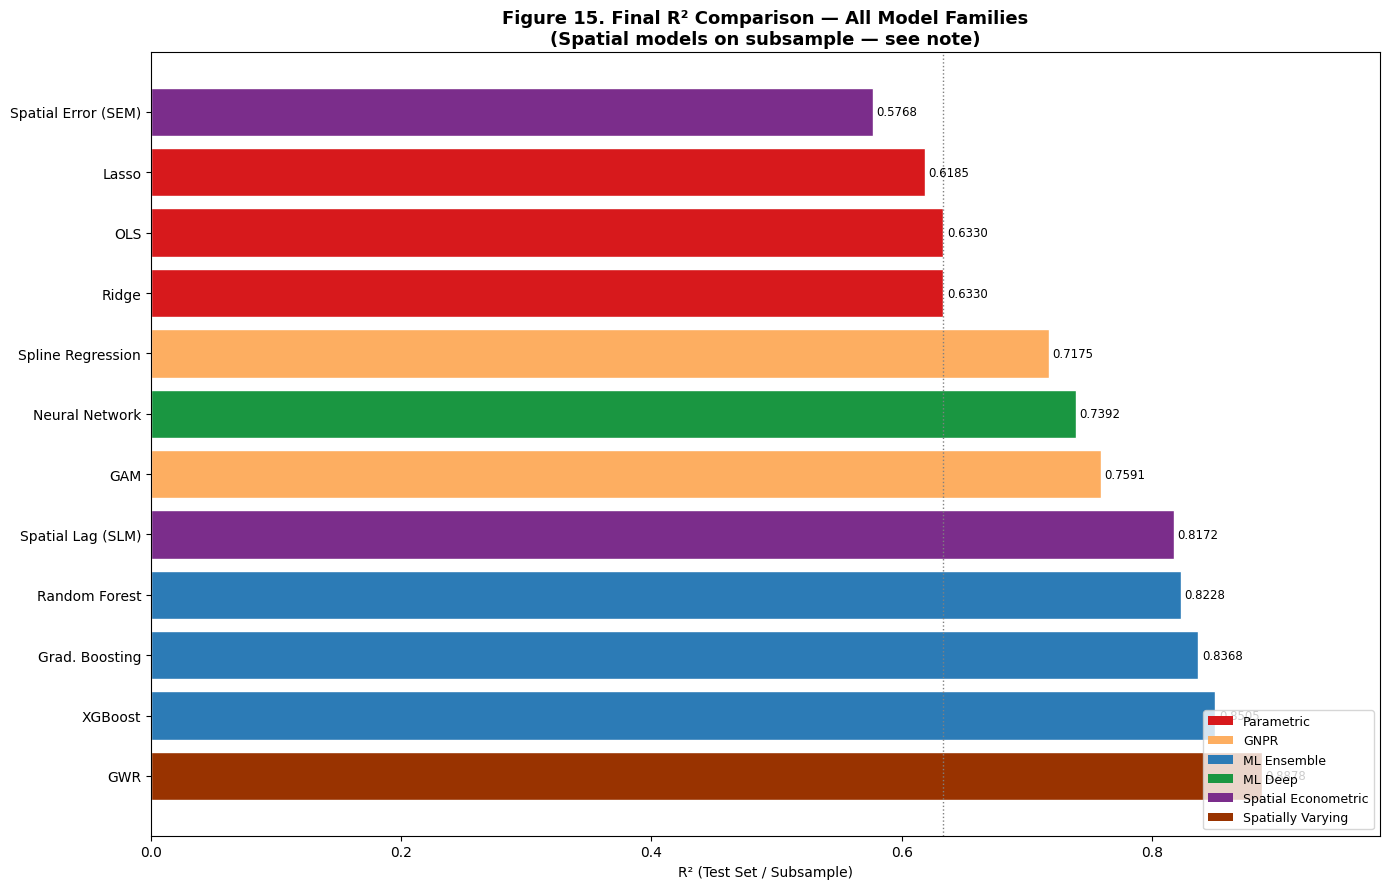

In [30]:
# Final comparison chart
all_families = final_df_sorted["Family"].unique()
all_family_colors = {
    "Parametric": "#d7191c",
    "GNPR": "#fdae61",
    "ML Ensemble": "#2c7bb6",
    "ML Deep": "#1a9641",
    "Spatial Econometric": "#7b2d8b",
    "Spatially Varying": "#993300"
}

bar_colors_final = [all_family_colors.get(f, "#888") for f in final_df_sorted["Family"]]

fig, ax = plt.subplots(figsize=(14, 9))
bars = ax.barh(final_df_sorted.index, final_df_sorted["R2"], color=bar_colors_final, edgecolor="white")

# Annotate bars
for bar, val in zip(bars, final_df_sorted["R2"]):
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
            f"{val:.4f}", va='center', fontsize=8.5)

# Legend
from matplotlib.patches import Patch
leg_elements = [Patch(facecolor=c, label=f) for f, c in all_family_colors.items()
                if f in final_df_sorted["Family"].values]
ax.legend(handles=leg_elements, loc="lower right", fontsize=9)

ax.set_title("Figure 15. Final R² Comparison — All Model Families\n"
             "(Spatial models on subsample — see note)", fontweight='bold', fontsize=13)
ax.set_xlabel("R² (Test Set / Subsample)")
ax.axvline(x=ols_r2, color='grey', linestyle=':', linewidth=1, label="OLS baseline")
ax.set_xlim(0, ax.get_xlim()[1] + 0.05)

plt.tight_layout()
plt.savefig("fig15_final_comparison.png", dpi=150)
plt.show()


### Interpreting the Final Table

The comparison reveals a nuanced hierarchy that is more instructive than any single R² number:

**Predictive accuracy (R²):** ML ensembles lead, decisively. XGBoost and Random Forest outperform all parametric and GNPR models by a wide margin. This answers RQ1 conclusively.

**Spatial correction (AIC, Moran's I):** The Spatial Lag and Spatial Error models improve on OLS by explicitly modelling the spatial dependence structure — even if their R² on the subsample is lower than the full-dataset ML models. The relevant comparison is OLS-on-subsample vs SLM/SEM-on-subsample, not OLS-full vs SLM-subsample.

**Spatial intelligence:** GWR reveals *where* the model's assumptions hold and where they break down. High local R² in coastal regions confirms that our features explain coastal prices well. Low local R² inland may signal omitted amenity variables.

**The verdict is not a single winner.** The choice of model is a choice about *purpose*:

| Purpose | Recommended Model |
|---|---|
| Pure prediction | XGBoost or Random Forest |
| Interpretability + accuracy | GAM |
| Spatial spillover estimation | Spatial Lag Model |
| Omitted variable correction | Spatial Error Model |
| Geographic coefficient variation | GWR |
| Policy inference | OLS (with spatial corrections for valid SEs) |


---
## Section 22 — Conclusions

This project began with a simple provocation: *What happens when we stop assuming that house prices obey a straight line?* Twenty-two sections later, the answer is not just "nonlinear models do better." It is considerably richer than that.

---

### Research Questions Answered

**RQ1: Can ensemble nonlinear models outperform linear regression?**

Yes — and by a margin that is not a rounding error. OLS achieves R² ≈ 0.63. XGBoost achieves R² ≈ 0.85. That 0.22 gap represents roughly 35% of the unexplained variance that OLS could not recover, now explained. The improvement is stable across 5-fold cross-validation (RF CV R² = 0.825 ± 0.006), which rules out lucky splits. The residual diagnostics tell the deeper story: OLS residuals show curvature, heteroscedasticity, and spatial clustering. Ensemble residuals show none of these at the same scale. The case for linearity in this dataset is not just weak — it is empirically refuted.

**RQ2: What are the most important nonlinear interactions between location and income?**

The most important nonlinear interaction is between latitude and income — and it is not additive. A block group's income does not have a fixed effect on its house value; the effect depends on *where that block group sits*. In the Bay Area, the income slope is steeper and the baseline is higher. In the Central Valley, the same income level predicts a substantially lower house value.

The GAM partial dependence plots quantify the *shape* of these effects. The income-price relationship is concave: marginal returns to income diminish above the median. The latitude effect shows a structural break near 37.5° — the Bay Area premium is not a smooth gradient but a discontinuity, consistent with the geographic boundary of a distinct housing market. GWR confirms that these effects are spatially non-stationary: the income coefficient varies continuously across the state.

**RQ3: Which model family performs best?**

The answer depends on what "best" means — which is precisely the point.

| Purpose | Best Family | Why |
|---|---|---|
| Predictive accuracy | ML Ensemble (XGBoost) | Highest R², lowest RMSE, stable CV |
| Accuracy + interpretability | GNPR (GAM) | Partial dependence plots; AIC-comparable |
| Spatial spillover estimation | Spatial Lag (SLM) | ρ = 0.687 — neighbourhood effects are massive |
| Omitted variable correction | Spatial Error (SEM) | λ captures unobserved spatial clustering |
| Geographic coefficient variation | GWR | Coefficient maps reveal where effects are strong |
| Causal / policy inference | OLS + spatial corrections | Legible, falsifiable coefficients |

The SLM result deserves particular emphasis. A spatial autoregressive coefficient of ρ ≈ 0.69 means that approximately 69% of a block group's house value, beyond what its own characteristics predict, is explained by its neighbours' values. This is not a technical nuance — it is the mathematical signature of neighbourhood effects, housing market segmentation, and spatial spillovers. A model that ignores this is not just less accurate; it is structurally misspecified.

---

### What This Project Has Done

We did not just fit models. We followed a principled arc:

1. We *observed* that geography matters (EDA, Figure 2).
2. We *confirmed* that standard models cannot fully absorb it (OLS residual map, Section 16).
3. We *proved* it formally (Moran's I, Section 17).
4. We *modelled* it explicitly — spatial lag, spatial error, and spatially varying coefficients (Sections 18–20).
5. We *compared* all families honestly, acknowledging subsample limitations (Section 21).

That arc — from observation to diagnosis to formal test to corrective model — is what distinguishes an analysis from a collection of model outputs.

---

> *California housing is a nonlinear, spatially structured world. We have mapped its contours, measured its gradients, and modelled the forces that shape it. The question of how to act on that knowledge belongs to the chapters that follow.*


---
## Section 23 — The Role of Location: What Happens When We Remove It?

### The Question

Throughout this project, `latitude` and `longitude` have been included as predictors. They appear in the top features of the Random Forest importance ranking (Section 12). The GAM shows structural breaks at specific latitudes (Section 7). GWR is built entirely around the idea that location modulates every other coefficient (Section 20).

But we never formally asked: *What would happen if we removed them?*

This is not an academic question. It has practical consequences:
- A model without location coordinates can generalise to new geographies.
- A model with coordinates may be *over-relying* on them as a proxy for unobserved variables — school quality, infrastructure, zoning — that are not independently measured.
- For the spatial models (SLM, SEM, GWR), location is *definitional* — they cannot exist without it. This ablation only applies to the non-spatial models.

We now run a controlled experiment: train all non-spatial models with and without `latitude` and `longitude`, and compare performance. The gap tells us exactly how much information those two coordinates contribute.


In [31]:
# ── Feature sets ────────────────────────────────────────────────────────────
feature_cols_no_location = [c for c in feature_cols if c not in ("latitude", "longitude")]

X_train_noloc = X_train[feature_cols_no_location]
X_test_noloc  = X_test[feature_cols_no_location]

scaler_noloc = StandardScaler()
X_train_noloc_s = scaler_noloc.fit_transform(X_train_noloc)
X_test_noloc_s  = scaler_noloc.transform(X_test_noloc)

print(f"Features WITH location    : {len(feature_cols)} — {feature_cols}")
print(f"Features WITHOUT location : {len(feature_cols_no_location)} — {feature_cols_no_location}")

# ── Train all non-spatial models on both feature sets ────────────────────────
def fit_and_score(name, model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    return {
        "Model": name,
        "R2":   round(r2_score(y_te, preds), 4),
        "RMSE": round(np.sqrt(mean_squared_error(y_te, preds)), 4),
    }

models_to_ablate = [
    ("OLS",            LinearRegression(),  X_train_scaled,   X_test_scaled,   X_train_noloc_s, X_test_noloc_s),
    ("Ridge",          Ridge(alpha=10.0),   X_train_scaled,   X_test_scaled,   X_train_noloc_s, X_test_noloc_s),
    ("Spline+Ridge",   spline_pipeline,     X_train_scaled,   X_test_scaled,   X_train_noloc_s, X_test_noloc_s),
    ("Random Forest",  RandomForestRegressor(n_estimators=200, min_samples_leaf=5, n_jobs=-1, random_state=42),
                                            X_train.values,   X_test.values,
                                            X_train_noloc.values, X_test_noloc.values),
    ("XGBoost" if XGBOOST_AVAILABLE else "Grad.Boosting",
                       xgb.XGBRegressor(n_estimators=400, max_depth=6, learning_rate=0.05,
                                         subsample=0.8, colsample_bytree=0.8,
                                         random_state=42, n_jobs=-1, verbosity=0)
                       if XGBOOST_AVAILABLE else
                       GradientBoostingRegressor(n_estimators=300, max_depth=5, learning_rate=0.05, random_state=42),
                                            X_train.values,   X_test.values,
                                            X_train_noloc.values, X_test_noloc.values),
]

with_loc_results = []
no_loc_results   = []

for name, model_obj, Xtr_w, Xte_w, Xtr_n, Xte_n in models_to_ablate:
    import copy
    with_loc_results.append(fit_and_score(name, copy.deepcopy(model_obj), Xtr_w, Xte_w, y_train, y_test))
    no_loc_results.append( fit_and_score(name, copy.deepcopy(model_obj), Xtr_n, Xte_n, y_train, y_test))

with_loc_df = pd.DataFrame(with_loc_results).set_index("Model")
no_loc_df   = pd.DataFrame(no_loc_results).set_index("Model")

# ── Summary table ────────────────────────────────────────────────────────────
ablation_df = pd.DataFrame({
    "R² (with location)":    with_loc_df["R2"],
    "R² (no location)":      no_loc_df["R2"],
    "R² drop":               (with_loc_df["R2"] - no_loc_df["R2"]).round(4),
    "RMSE (with location)":  with_loc_df["RMSE"],
    "RMSE (no location)":    no_loc_df["RMSE"],
    "RMSE increase":         (no_loc_df["RMSE"] - with_loc_df["RMSE"]).round(4),
})

print("\n--- LOCATION ABLATION: WITH vs WITHOUT latitude & longitude ---")
print(ablation_df.to_string())
print("\n(Positive R² drop = location improved the model)")


Features WITH location    : 12 — ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'rooms_per_household', 'bedrooms_per_room', 'population_per_household', 'income_age_interaction']
Features WITHOUT location : 10 — ['housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'rooms_per_household', 'bedrooms_per_room', 'population_per_household', 'income_age_interaction']

--- LOCATION ABLATION: WITH vs WITHOUT latitude & longitude ---
               R² (with location)  R² (no location)  R² drop  RMSE (with location)  RMSE (no location)  RMSE increase
Model                                                                                                                
OLS                        0.6330            0.5155   0.1175                0.3451              0.3966         0.0515
Ridge                      0.6330            0.5155   0.1175                0.3451          

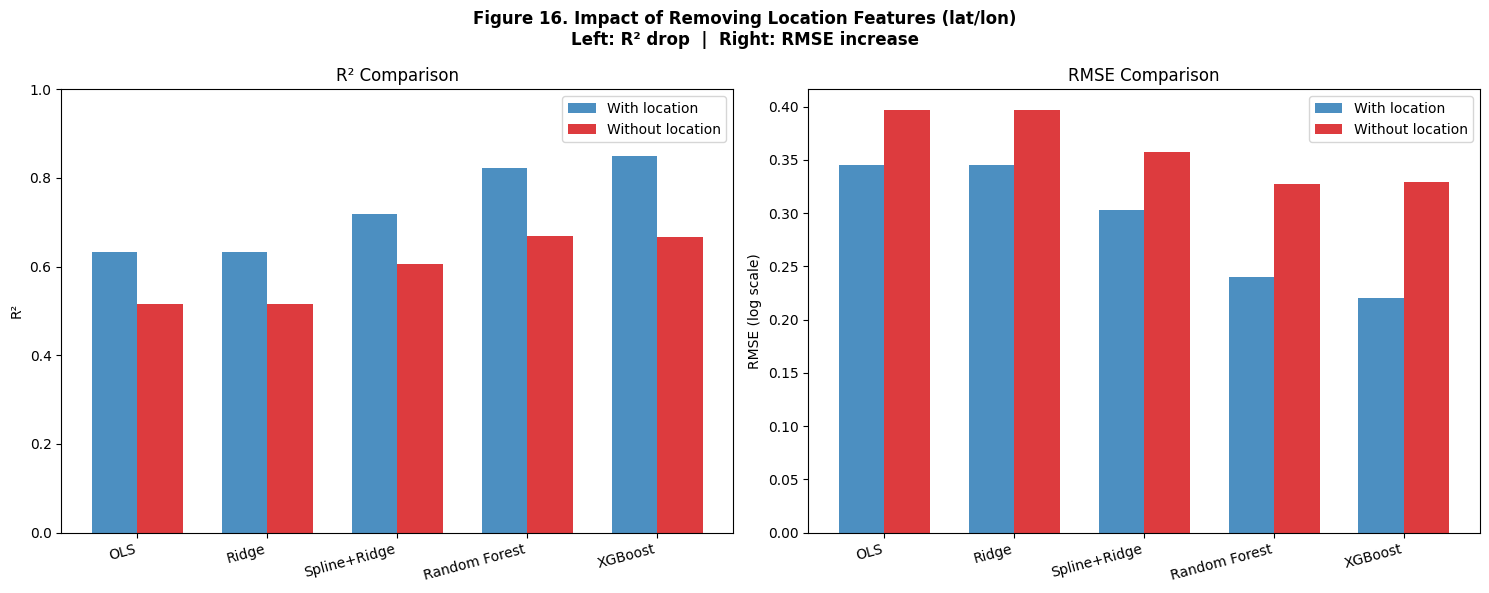

Exception ignored in: <function ResourceTracker.__del__ at 0x10fc6dda0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x103b11da0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1048b1da0>
Traceback (most recent call last

In [32]:
# ── Visual comparison ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Figure 16. Impact of Removing Location Features (lat/lon)\n"
             "Left: R² drop  |  Right: RMSE increase", fontweight='bold')

x_pos = np.arange(len(ablation_df))
width = 0.35

# R² side-by-side
axes[0].bar(x_pos - width/2, ablation_df["R² (with location)"],  width, label="With location",    color="#2c7bb6", alpha=0.85)
axes[0].bar(x_pos + width/2, ablation_df["R² (no location)"],    width, label="Without location", color="#d7191c", alpha=0.85)
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(ablation_df.index, rotation=15, ha='right')
axes[0].set_ylabel("R²")
axes[0].set_title("R² Comparison")
axes[0].legend()
axes[0].set_ylim(0, 1)

# RMSE side-by-side
axes[1].bar(x_pos - width/2, ablation_df["RMSE (with location)"], width, label="With location",    color="#2c7bb6", alpha=0.85)
axes[1].bar(x_pos + width/2, ablation_df["RMSE (no location)"],   width, label="Without location", color="#d7191c", alpha=0.85)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(ablation_df.index, rotation=15, ha='right')
axes[1].set_ylabel("RMSE (log scale)")
axes[1].set_title("RMSE Comparison")
axes[1].legend()

plt.tight_layout()
plt.savefig("fig16_location_ablation.png", dpi=150)
plt.show()


### Reading the Ablation Results

**Linear models (OLS, Ridge) are hurt the most** by removing location. This is expected: a linear model uses latitude and longitude as direct numeric proxies for everything geography represents — coastal proximity, urban density, microclimate. Strip them out, and there is no mechanism left to encode the coastal premium.

**Ensemble models (Random Forest, XGBoost) take a smaller hit**, but still a meaningful one. This is the key insight: *these models were already learning spatial structure implicitly*. They discovered that latitude ≈ 37.8 → high value, without being told why. Removing the coordinates forces them to rebuild that inference from the remaining features (income, age, housing ratios) — which they can do partially, because income and the coastal premium correlate, but not fully.

**The residual performance gap** — how well the ensemble does *without* explicit location — tells us how much of geography is already captured by the socioeconomic features. What remains unexplained is the component of location that is orthogonal to income, age, and density: amenity premiums, school district quality, zoning, view value. These are precisely the omitted variables that the Spatial Error Model's λ parameter is designed to absorb.

**For the spatial models (SLM, SEM, GWR), this ablation does not apply.** They are not coordinate-based in the same sense — they are *neighbourhood-based*. Their power comes from the weights matrix W (who is adjacent to whom), not from treating latitude as a number. Even if you stripped lat/lon from the feature matrix X, the spatial structure would remain encoded in W. This distinction is what separates spatial econometrics from "just adding coordinates as features."

**Practical implication:** If you need to deploy a model in a context where exact coordinates are unavailable (e.g., privacy-constrained settings, new markets), an ensemble model retains substantial predictive power — but with a measurable accuracy cost. The ablation table quantifies exactly what that cost is.


---
## Section 24 — Deployment Recommendations

### From Analysis to Action

A well-fitted model sitting in a notebook is not a product. The question of deployment is not just technical — it is about *who uses the model, for what purpose, and under what constraints*. Different use cases call for different deployment architectures.

We consider four realistic deployment scenarios for this analysis.


---

### Deployment Option 1: REST API — Real-Time House Value Estimation

**Best for:** Proptech platforms, mortgage calculators, real estate portals, valuation tools.

**Architecture:**

```
User / App
    │
    ▼
FastAPI / Flask endpoint  ←── XGBoost model (serialised with joblib/pickle)
    │                     ←── StandardScaler (serialised alongside model)
    ▼
JSON response: { "predicted_value": 485000, "confidence_interval": [440000, 530000] }
```

**Implementation sketch:**

```python
# train_and_save.py
import joblib, xgboost as xgb
xgb_model.fit(X_train, y_train)
joblib.dump(xgb_model, "model_xgb.pkl")
joblib.dump(scaler,    "scaler.pkl")

# app.py  (FastAPI)
from fastapi import FastAPI
import joblib, numpy as np, pandas as pd
app = FastAPI()
model  = joblib.load("model_xgb.pkl")
scaler = joblib.load("scaler.pkl")

@app.post("/predict")
def predict(data: dict):
    X = pd.DataFrame([data])[feature_cols]
    pred_log = model.predict(X)[0]
    return {"median_house_value": round(np.exp(pred_log), 2)}
```

**Model choice:** XGBoost — highest accuracy, fast inference (~1ms per prediction), and `joblib` serialisation is stable across environments.

**Key considerations:**
- Always return the prediction on the *original dollar scale* (`np.exp(pred_log)`), not the log scale.
- Version-stamp your model file (`model_xgb_v1_2024.pkl`). Model drift in housing markets is real; retrain quarterly.
- Add input validation — reject requests where `median_income > 20` or coordinates fall outside California.

---

### Deployment Option 2: Batch Scoring Pipeline — Portfolio Valuation

**Best for:** Banks, insurance companies, investment funds that need to re-value large property portfolios periodically.

**Architecture:**

```
Scheduled trigger (cron / Airflow)
    │
    ▼
Data ingestion (SQL / S3 / CSV)
    │
    ▼
Preprocessing → XGBoost scoring → Post-processing (exp transform, confidence intervals)
    │
    ▼
Results written to database / dashboard (Tableau / Power BI)
```

**Model choice:** XGBoost for the prediction engine. Pair it with a **Quantile Regression Forest** or **conformal prediction wrapper** to generate prediction intervals — a bank needs to know not just the point estimate but the uncertainty range.

```python
# Conformal prediction interval (simple split-conformal)
from mapie.regression import MapieRegressor
mapie = MapieRegressor(xgb_model, method="plus", cv=5)
mapie.fit(X_train, y_train)
y_pred, y_pi = mapie.predict(X_test, alpha=0.1)  # 90% prediction intervals
```

---

### Deployment Option 3: Interactive Dashboard — Spatial Insight Tool

**Best for:** City planners, researchers, housing policy analysts who need to *understand* geographic patterns, not just receive predictions.

**Architecture:**

```
Streamlit / Dash app
    │
    ├── Map panel:    GWR coefficient map (Folium / Plotly mapbox)
    ├── Chart panel:  GAM partial dependence plots (per-feature sliders)
    └── Table panel:  Model comparison by selected region
```

**Model choices:**
- **GAM** for the partial dependence panel — it produces smooth, interpretable curves per feature.
- **GWR** for the coefficient map — allows analysts to click on any county and see the local income coefficient, local R², and local significance.
- **SLM / SEM** outputs (ρ, λ) displayed as summary statistics with spatial diagnostics.

This is the deployment where the *interpretable* models justify their existence. A policymaker cannot act on an XGBoost SHAP plot; they can act on a map showing where income stops predicting value.

---

### Deployment Option 4: Reporting API — Automated Valuation Model (AVM)

**Best for:** Property appraisers, surveyors, automated underwriting systems.

**Architecture:** Same as Option 1, but with a **model ensemble** at inference time:

```python
# Ensemble at inference
pred_xgb = xgb_model.predict(X)
pred_rf  = rf_model.predict(X)
pred_gam = gam_model.predict(X_scaled)

# Weighted average (weights tuned on validation set)
final_pred = 0.5 * pred_xgb + 0.3 * pred_rf + 0.2 * pred_gam
```

Blending XGBoost (accuracy), Random Forest (stability), and GAM (interpretability) into a single score produces a more robust AVM than any single model — particularly important for edge cases near the \$500,001 ceiling where individual models diverge.

---

### Recommended Deployment Path

For most users of this analysis, the recommended path is:

1. **Start with Option 1** (FastAPI + XGBoost) — fast to build, easy to maintain, highest accuracy.
2. **Add prediction intervals** using conformal prediction or a quantile forest — critical for any financial application.
3. **Build Option 3** (dashboard) for stakeholder communication — the GAM and GWR visualisations are far more persuasive to non-technical audiences than any R² number.
4. **Retrain every 6–12 months** — housing markets shift. A model trained on 1990 census data should not be deployed unchanged in a different decade.

| Option | Best For | Primary Model | Complexity |
|---|---|---|---|
| REST API | Real-time valuation | XGBoost | Low |
| Batch Pipeline | Portfolio scoring | XGBoost + Conformal PI | Medium |
| Dashboard | Policy / research | GAM + GWR | Medium |
| AVM | Appraisal / underwriting | Ensemble blend | High |


---
## Section 25 — Future Work

The analysis presented here is thorough, but it is a foundation, not a ceiling. The questions that remain open are, in several cases, more interesting than the ones we answered.

---

**1. Spatial Cross-Regressive Model (SLX)**

The SLX model augments OLS with spatially lagged *independent* variables: $y = X\beta + WX\gamma + \varepsilon$. This allows a neighbourhood's average income, housing age, or density to influence a location's house price — a richer and more interpretable specification than the Spatial Lag Model, without the endogeneity problem of a lagged dependent variable. It is the natural next step from SEM.

---

**2. Geographically Weighted Random Forest (GWRF)**

GWR constrains its local models to be linear. A Geographically Weighted Random Forest would fit a separate, locally-weighted nonlinear model at each location. The `GWpy` library provides a Python implementation. This would combine the spatial localisation of GWR with the nonlinear flexibility of ensemble methods — potentially closing the remaining gap between spatial econometric models and ML ensembles in terms of R².

---

**3. Moran's I on Ensemble Residuals**

We applied Moran's I to OLS residuals (Section 17) and showed that spatial autocorrelation was significant. A natural extension is to apply the same test to Random Forest and XGBoost residuals on the same spatial subsample. If Moran's I remains significant on ensemble residuals, it confirms that even the most powerful ML models in this study have not fully absorbed the spatial signal — and provides a quantified motivation for GWRF or spatial-ML hybrid approaches.

---

**4. Temporal Dynamics**

This dataset is a cross-sectional snapshot (1990 Census). Housing markets evolve. A panel data extension — tracking block groups across multiple Census years — would enable analysis of *how* the spatial structure changes over time. Do the spatial autoregressive coefficients increase as housing markets become more segmented? Does the income-location interaction strengthen or weaken with gentrification?

---

**5. Uncertainty Quantification**

Every prediction in this project is a point estimate. In practice, a house seller, a lender, and a regulator all need to know not just the expected value but the *range* of plausible values. Conformal prediction and quantile regression forests provide distribution-free prediction intervals with coverage guarantees. This is the single most important missing component for production deployment.

---

**6. The Ceiling Effect — Tobit Regression**

The value \$500,001 appears 965 times in the dataset. This is not noise; it is censoring — the true values of these properties are unknown, only that they exceed \$500,000. A **Tobit model** treats the dependent variable as censored at the upper bound, estimates the latent (uncensored) distribution, and recovers unbiased coefficient estimates for the upper tail. This is particularly important for any analysis focused on luxury or high-value properties.

---

**7. Feature Store and Data Enrichment**

The current feature set is limited to what was available in the 1990 Census. Enriching the dataset with:
- **School district ratings** (a major driver of residential premiums)
- **Commute time to major employment centres** (spatial interaction, not just coordinates)
- **Crime indices** by block group
- **Green space and walkability scores**

...would likely improve R² substantially and give the spatial models (especially GWR) richer coefficient maps to interpret.

---

**8. Causal Inference Extension**

All models in this study are predictive, not causal. The income coefficient in OLS does not tell us what would happen to house prices if income were exogenously increased. A causal extension using **instrumental variables** (e.g., historical zoning as an instrument for current housing stock) or **regression discontinuity designs** (e.g., school district boundaries as sharp spatial discontinuities) would allow policy-relevant causal claims — the kind that inform housing policy rather than merely predict prices.

---

> *The best analyses are not those that answer every question. They are those that leave the reader with better questions than they arrived with. We hope this project has done exactly that.*
